In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import collections
import xarray as xr
xr.set_options(keep_attrs=True)
import netCDF4 as nc
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units
from scipy.stats import ttest_ind, ttest_rel
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import binned_statistic
from datetime import datetime
import cf_xarray
import cftime
import pyproj
from pyproj import Geod

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing
from shapely.geometry import LineString, Point
import regionmask

import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory
opath='/home/dmkumar/JupyterLinks/notebooks/topo_nam'

In [3]:
def match_lat_lon_names(ds):
    for lat_name in ['y', 'latitude', 'nav_lat']:
        if (lat_name in ds.coords) and ('lat' not in ds.coords):
            ds=ds.rename({lat_name: 'lat'})
        else:
            ds=ds
    for lon_name in ['x', 'longitude', 'nav_lon']:
        if (lon_name in ds.coords) and ('lon' not in ds.coords):
            ds = ds.rename({lon_name: 'lon'})
        else:
            ds=ds
    return ds

def jas_seasonal_mean(ds):
    """
    Calculate seasonal mean accounting for varying month lengths
    ** assumes no leap **
    """    
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    jas_weighted_mean = (jas * weights).sum(dim='time') / weights.sum(dim='time')
    return jas_weighted_mean

def jas_yearly_mean(ds):
    """
    Calculate jas seasonal mean for each year, accounting for varying month lengths
    ** assumes no leap **
    """ 
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    jas_yearly_weighted_mean = ((jas * weights).groupby('time.year').sum(dim='time') / weights.groupby('time.year').sum(dim='time'))
    return jas_yearly_weighted_mean

def rotated_box(lon0, lat0, width, height, angle_deg):
    angle = np.deg2rad(angle_deg)

    # Half sizes
    dx = width / 2
    dy = height / 2

    # Corners relative to center
    corners = np.array([
        [-dx, -dy],
        [ dx, -dy],
        [ dx,  dy],
        [-dx,  dy]
    ])

    # Rotation matrix
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    rotated = corners @ R.T
    rotated[:, 0] += lon0
    rotated[:, 1] += lat0

    return rotated

def regional_weighted_mean(da, region_name):

    mask3d = regions.mask_3D(da)
    region_index = regions.names.index(region_name)
    masked = da.where(mask3d.sel(region=region_index))
    weights = np.cos(np.deg2rad(da.lat))
    
    return masked.weighted(weights).mean(("lat", "lon"))

In [5]:
models=['CAM-MPAS',
        'CAMS-CSM1-0',
        'CMCC-CM2',
        'CNRM-CM6-1',
        'EC-Earth3P',
        'ECMWF-IFS',
        'FGOALS-f3',
        'GFDL-CM4',
        'HadGEM3-GC31',
        'HiRAM-SIT',
        'INM-CM5',
        'IPSL-CM6A',
        'MPI-ESM1-2',
        'MRI-ESM2',
        'NICAM16']

lr_map = {
    'CAM-MPAS': ['CAM-MPAS-LR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0-LR'],
    'CMCC-CM2': ['CMCC-CM2-HR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1'],
    'EC-Earth3P': [],
    'ECMWF-IFS': ['ECMWF-IFS-LR'],
    'FGOALS-f3': ['FGOALS-f3-L'],
    'GFDL-CM4': ['GFDL-CM4'],
    'HadGEM3-GC31': ['HadGEM3-GC31-LM'],
    'HiRAM-SIT': [],
    'INM-CM5': ['INM-CM5-0'],
    'IPSL-CM6A': ['IPSL-CM6A-LR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-LR'],
    'MRI-ESM2': ['MRI-ESM2-0'],
    'NICAM16': [],
}

hr_map = {
    'CAM-MPAS': ['CAM-MPAS-HR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0'],
    'CMCC-CM2': ['CMCC-CM2-VHR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1-HR'],
    'EC-Earth3P': ['EC-Earth3P', 'EC-Earth3P-HR'],
    'ECMWF-IFS': ['ECMWF-IFS-HR'],
    'FGOALS-f3': ['FGOALS-f3-H'],
    'GFDL-CM4': ['GFDL-CM4C192'],
    'HadGEM3-GC31': ['HadGEM3-GC31-MM', 'HadGEM3-GC31-HM'],
    'HiRAM-SIT': ['HiRAM-SIT-LR', 'HiRAM-SIT-HR'],
    'INM-CM5': ['INM-CM5-H'],
    'IPSL-CM6A': ['IPSL-CM6A-ATM-HR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-HR', 'MPI-ESM1-2-XR'],
    'MRI-ESM2': ['MRI-AGCM3-2-H', 'MRI-AGCM3-2-S'],
    'NICAM16': ['NICAM16-7S', 'NICAM16-8S'],
}

In [6]:
## +++ LOAD HRMIP DATA +++ ##

# store file paths in dictionary
files = {}
varn = 'pr'
case = 'highresSST-present'

for model in models:
    for cfg in lr_map[model] + hr_map[model]:
        files[cfg] = (f"{dpath0}/hrmip/{case}/{varn}/{varn}.Amon.{case}.{cfg}.nc")

dat = { 'lr': {}, 'hr': {} }
dat_na = { 'lr': {}, 'hr': {} }
varn = 'pr'
# lat lon bounds
latmin = 10
latmax = 70
lonmin = 200
lonmax = 300

print("Working on...")
for model in models:
    # low resolution
    for cfg in lr_map[model]:
        print(f"LR -> {cfg}")
        ds = xr.open_dataset(files[cfg], chunks={'time': 12})['pr']
        # concatenating in nco might not have led to a monotonically increasing time variable somehow
        ds = ds.sortby('time').sel(time=slice('1950','2014'))
        # make sure names of coordinate variables match
        ds = match_lat_lon_names(ds)
        ds = ds * 86400  # mm/s → mm/day
        # clean up
        ds = ds.squeeze()
        ds = ds.drop_vars([c for c in ['member_id', 'dcpp_init_year'] if c in ds.coords])
        # add to dict
        dat['lr'][cfg] = ds
        dat_na['lr'][cfg] = ds.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        
    # high resolution
    for cfg in hr_map[model]:
        print(f"HR -> {cfg}")
        ds = xr.open_dataset(files[cfg], chunks={'time': 12})['pr']
        # concatenating in nco might not have led to a monotonically increasing time variable somehow
        ds = ds.sortby('time').sel(time=slice('1950','2014'))
        # make sure names of coordinate variables match
        ds = match_lat_lon_names(ds)
        # clean up
        ds = ds * 86400
        ds = ds.squeeze()
        ds = ds.drop_vars([c for c in ['member_id', 'dcpp_init_year'] if c in ds.coords])
        # add to dict
        dat['hr'][cfg] = ds
        dat_na['hr'][cfg] = ds.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        
print("Done.")

Working on...
LR -> CAM-MPAS-LR
HR -> CAM-MPAS-HR
LR -> CAMS-CSM1-0-LR
HR -> CAMS-CSM1-0
LR -> CMCC-CM2-HR4
HR -> CMCC-CM2-VHR4
LR -> CNRM-CM6-1
HR -> CNRM-CM6-1-HR
HR -> EC-Earth3P
HR -> EC-Earth3P-HR
LR -> ECMWF-IFS-LR
HR -> ECMWF-IFS-HR
LR -> FGOALS-f3-L
HR -> FGOALS-f3-H
LR -> GFDL-CM4
HR -> GFDL-CM4C192
LR -> HadGEM3-GC31-LM
HR -> HadGEM3-GC31-MM
HR -> HadGEM3-GC31-HM
HR -> HiRAM-SIT-LR
HR -> HiRAM-SIT-HR
LR -> INM-CM5-0
HR -> INM-CM5-H
LR -> IPSL-CM6A-LR
HR -> IPSL-CM6A-ATM-HR
LR -> MPI-ESM1-2-LR
HR -> MPI-ESM1-2-HR
HR -> MPI-ESM1-2-XR
LR -> MRI-ESM2-0
HR -> MRI-AGCM3-2-H
HR -> MRI-AGCM3-2-S
HR -> NICAM16-7S
HR -> NICAM16-8S
Done.


In [7]:
## +++ LOAD OBS DATA +++ ##

# product files
obs_prods=['imerg', 'trmm', 'gpcc']
obs_files={}
    
obs_files['imerg'] = f'{dpath0}/obs_data/prec/imerg.gn.timeseries.2001-2018.nc' 
obs_files['trmm'] = f'{dpath0}/obs_data/prec/pr_TRMM-L3_v7-7A_199801-201312.nc' 
obs_files['gpcc'] = f'{dpath0}/obs_data/prec/gpcc.precip.mon.rate.0.25x0.25.v2020.nc'

obs_dat={ 'imerg' : {},
          'trmm'  : {},
          'gpcc'  : {} }

obs_dat_na={ 'imerg' : {},
             'trmm'  : {},
             'gpcc'  : {} }

print('Working on...')
for prod in obs_prods:
    print(f"{prod}")
    # pre-processing
    if prod == 'imerg':
        ds = xr.open_dataset(obs_files[prod], chunks={'time':12}).precipitation * 24 # convert from mm/hr to mm/day
        ds = ds.transpose('time','lat','lon')
        ds.attrs['units'] = 'mm/day'
        ds.attrs['Units'] = 'mm/day'
        ds = lonFlip(ds)
    if prod == 'trmm':
        ds = xr.open_dataset(obs_files[prod], chunks={'time':12}).pr * 86400 # convert from kg m-2 s-1 to mm/day
    if prod == 'gpcc':
        ds = xr.open_dataset(obs_files[prod], chunks={}).precip.sortby("lat") 
    # add data to dictionary
    obs_dat[prod] = ds
    obs_dat_na[prod] = ds.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
    del ds
print('Done.')

Working on...
imerg
trmm
gpcc
Done.


In [8]:
#=== calculate seasonal means

jas_mean = {'lr': {},
            'hr': {},
            'obs': {'imerg': {}, 'trmm': {}, 'gpcc':{} },
        }

ann_jas_mean = {'lr': {},
                'hr': {},
                'obs': {'imerg': {}, 'trmm': {}, 'gpcc':{} },
            }

for res in ['lr', 'hr']:
    for cfg, ds in dat_na[res].items():
        jas_mean[res][cfg] = jas_seasonal_mean(ds)
        ann_jas_mean[res][cfg] = jas_yearly_mean(ds)

for res in ['obs']:
    for prod in obs_prods:
        jas_mean[res][prod] = jas_seasonal_mean(obs_dat_na[prod])
        ann_jas_mean[res][prod] = jas_yearly_mean(obs_dat_na[prod])

print('Done.')

Done.


In [9]:
#=== Regrid obs to each model grid for comparison
obs_jas_mean_regrid = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
obs_ann_jas_mean_regrid = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}

for prod in obs_prods:
    for res in ['lr', 'hr']:
        for cfg, ds in dat_na[res].items():
            obs_jas_mean_regrid[prod][res][cfg] = jas_mean['obs'][prod].interp(lat=ds.lat, lon=ds.lon)
            obs_ann_jas_mean_regrid[prod][res][cfg] = ann_jas_mean['obs'][prod].interp(lat=ds.lat, lon=ds.lon)

In [10]:
#=== Significance testing
diff      = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
diff_mask = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
ptvals    = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}

print('Significance testing for:')
for prod in obs_prods:
    print(f'\n{prod}')
    for res in ['lr', 'hr']:
        print(f'->{res}')
        for cfg in dat[res]:
            print(f'...{cfg}')
            d, m, p = sigtest2n(ann_jas_mean[res][cfg], obs_ann_jas_mean_regrid[prod][res][cfg],
                                jas_mean[res][cfg],     obs_jas_mean_regrid[prod][res][cfg])
            diff[prod][res][cfg] = d
            diff_mask[prod][res][cfg] = m
            ptvals[prod][res][cfg] = p

print('Done.')

Significance testing for:

imerg
->lr
...CAM-MPAS-LR
...CAMS-CSM1-0-LR
...CMCC-CM2-HR4
...CNRM-CM6-1
...ECMWF-IFS-LR
...FGOALS-f3-L
...GFDL-CM4
...HadGEM3-GC31-LM
...INM-CM5-0
...IPSL-CM6A-LR
...MPI-ESM1-2-LR
...MRI-ESM2-0
->hr
...CAM-MPAS-HR
...CAMS-CSM1-0
...CMCC-CM2-VHR4
...CNRM-CM6-1-HR
...EC-Earth3P
...EC-Earth3P-HR
...ECMWF-IFS-HR
...FGOALS-f3-H
...GFDL-CM4C192
...HadGEM3-GC31-MM
...HadGEM3-GC31-HM
...HiRAM-SIT-LR
...HiRAM-SIT-HR
...INM-CM5-H
...IPSL-CM6A-ATM-HR
...MPI-ESM1-2-HR
...MPI-ESM1-2-XR
...MRI-AGCM3-2-H
...MRI-AGCM3-2-S
...NICAM16-7S
...NICAM16-8S

trmm
->lr
...CAM-MPAS-LR


KeyError: 'trmm'

In [11]:
#=== create combined dictionary (keyed by configuration)

obs_prods = ['imerg']

# lat/lon bounds
ymin, ymax = 15, 45
xmin, xmax = 240, 270

allmodels = {prod: {} for prod in obs_prods}
for prod in obs_prods:
    # low-resolution configurations
    for cfg, da in diff[prod]['lr'].items():
        allmodels[prod][cfg] = (da.sel(lat=slice(ymin, ymax), lon=slice(xmin, xmax)).load())

    # high-resolution configurations
    for cfg, da in diff[prod]['hr'].items():
        allmodels[prod][cfg] = (da.sel(lat=slice(ymin, ymax), lon=slice(xmin, xmax)).load())

sorted_models = {}
for prod in obs_prods:
    sorted_models[prod] = dict(sorted(allmodels[prod].items(),  key=lambda item: len(item[1].coords["lon"])))


#=== Store information about model resolution
allmodels_res = {}
# low-resolution configs
for cfg, da in dat['lr'].items():
    allmodels_res[cfg] = da.lon

# high-resolution configs
for cfg, da in dat['hr'].items():
    allmodels_res[cfg] = da.lon

allmodels_res = dict(sorted(allmodels_res.items(), key=lambda item: len(item[1]), reverse=False))

In [12]:
#=== GET INFO ABOUT MEDIAN AND MEAN MODEL RESOLUTIONS

# count number of longitude points for each configuration
lowres_counts = {cfg: len(da.lon) for cfg, da in dat['lr'].items()}
highres_counts = {cfg: len(da.lon) for cfg, da in dat['hr'].items()}

# compute medians
median_lowres = np.median(list(lowres_counts.values()))
median_highres = np.median(list(highres_counts.values()))

# compute means
mean_lowres = np.mean(list(lowres_counts.values()))
mean_highres = np.mean(list(highres_counts.values()))

# find configuration(s) exactly at the median
median_lowres_configs = [cfg for cfg, n in lowres_counts.items() if n == median_lowres]
median_highres_configs = [cfg for cfg, n in highres_counts.items() if n == median_highres]

# find configuration closest to the mean
mean_lowres_config = min(lowres_counts, key=lambda cfg: abs(lowres_counts[cfg] - mean_lowres))
mean_highres_config = min(highres_counts, key=lambda cfg: abs(highres_counts[cfg] - mean_highres))


print(f"Median low-resolution grid size (lon): {median_lowres}")
print(f"Configuration(s) with median low resolution: {median_lowres_configs}\n")
print(f"Median high-resolution grid size (lon): {median_highres}")
print(f"Configuration(s) with median high resolution: {median_highres_configs}\n")

print(f"Mean low-resolution grid size (lon): {mean_lowres}")
print(f"Closest configuration to mean low resolution: {mean_lowres_config}\n")
print(f"Mean high-resolution grid size (lon): {mean_highres}")
print(f"Closest configuration to mean high resolution: {mean_highres_config}")

Median low-resolution grid size (lon): 288.0
Configuration(s) with median low resolution: ['CMCC-CM2-HR4', 'FGOALS-f3-L', 'GFDL-CM4']

Median high-resolution grid size (lon): 720.0
Configuration(s) with median high resolution: ['CNRM-CM6-1-HR', 'ECMWF-IFS-HR', 'HiRAM-SIT-LR']

Mean low-resolution grid size (lon): 265.6666666666667
Closest configuration to mean low resolution: CNRM-CM6-1

Mean high-resolution grid size (lon): 892.7619047619048
Closest configuration to mean high resolution: CAMS-CSM1-0


In [13]:
# determine what the lowest resolution model of each set is based on length of lon dimension
lr_sorted = dict(sorted(dat['lr'].items(), key=lambda item: len(item[1].coords["lon"])))
hr_sorted = dict(sorted(dat['hr'].items(), key=lambda item: len(item[1].coords["lon"])))

In [14]:
lr_sorted.keys()
hr_sorted.keys()

dict_keys(['MPI-ESM1-2-HR', 'HadGEM3-GC31-MM', 'EC-Earth3P', 'IPSL-CM6A-ATM-HR', 'INM-CM5-H', 'GFDL-CM4C192', 'MRI-AGCM3-2-H', 'NICAM16-7S', 'CNRM-CM6-1-HR', 'ECMWF-IFS-HR', 'HiRAM-SIT-LR', 'CAMS-CSM1-0', 'MPI-ESM1-2-XR', 'EC-Earth3P-HR', 'HadGEM3-GC31-HM', 'CMCC-CM2-VHR4', 'NICAM16-8S', 'CAM-MPAS-HR', 'FGOALS-f3-H', 'HiRAM-SIT-HR', 'MRI-AGCM3-2-S'])

In [15]:
#=== Load topo data
etopo_full = xr.open_dataset(f'{dpath0}/topo_files/obs.etopo5.zsurf.nc').ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
etopoNA = etopo_full.where(etopo_full>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))

#=== calculate topo profile
etopo_profile = etopoNA.sel(lat=slice(ymin, ymax),
                            lon=slice(xmin, xmax)).mean(dim="lat", skipna=True)

# Figures

In [ ]:
# store info about magnitude of bias in low res models
parent_lr_bias = { domain: {} for domain in domains }

for domain in domains:
    for parent, cfgs in lr_map.items():
        lr_cfg = cfgs[0]
        parent_lr_bias[domain][parent]  = nam_bias['lr'][domain][lr_cfg]

# sort low res models by size of bias
parent_models = {}
for domain in domains:
    parent_models[domain] = sorted(parent_lr_bias[domain], key=lambda m: parent_lr_bias[domain][m])

# determine plotting x positions based on sorted model bias magnitudes
xpos = { domain: {} for domain in domains }
for domain in domains:
    xpos[domain] = {m: i for i, m in enumerate(parent_models[domain])}

# map configuration names to parent model names
cfg_to_parent = {}
for parent, cfgs in lr_map.items():
    for cfg in cfgs:
        cfg_to_parent[cfg] = parent
for parent, cfgs in hr_map.items():
    for cfg in cfgs:
        cfg_to_parent[cfg] = parent

## BIAS ALONG TRANSECT

In [ ]:
#=== Calculate bias along and across transect line ===#

# Define diagonal transect from NW (ymax, xmin) to SE (ymin, xmax)
npoints = 200  # resolution along the transect
lats = np.linspace(33, 20, npoints)
lons = np.linspace(247.5, 257.5, npoints)

# Compute distance along transect (in km)
geod = Geod(ellps="WGS84")
distances = [0]  # first point is 0 km
for i in range(1, len(lats)):
    _, _, d = geod.inv(lons[i-1], lats[i-1], lons[i], lats[i])  # meters
    distances.append(distances[-1] + d/1000)  # accumulate in km
distances = np.array(distances)

transect_vals = {}

for key in allmodels['imerg'].keys():
    da = allmodels['imerg'][key]
    
    # Create numpy arrays of dimensions and data values
    lat_vals = da['lat'].values
    lon_vals = da['lon'].values
    data_vals = da.values

    # Ensure lat is ascending for RegularGridInterpolator
    # --> climate data often has descending (i.e. N to S) lats
    if lat_vals[0] > lat_vals[-1]:
        lat_vals = lat_vals[::-1]
        data_vals = data_vals[::-1, :]
    
    # Create a bilinear interpolator over the (lat, lon) grid
    interp = RegularGridInterpolator(
        (lat_vals, lon_vals),
        data_vals,
        bounds_error=False,
        fill_value=np.nan
    )

    # Interpolate along transect
    points = np.array([lats, lons]).T
    transect_vals[key] = interp(points)


In [ ]:
# settings
text_kw={'size':18, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
text_kw1={'size':12, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'center'}
tsect_text_kw={'fontsize':10, 'fontweight':'bold', 'c':'k', 'ha':'left', 'va':'bottom'}
line_kw={'ls':'-', 'lw':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':10} 
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20)  # discrete steps for cbar
# topography contours
zlevels=np.linspace(800,3200,5)
# transect line
npoints = 200  # resolution along the transect
lats = np.linspace(33, 20, npoints)
lons = np.linspace(-112.5, -102.5, npoints)
transect_line = LineString(zip(lons, lats))
# transect line increments
step = 500  # km
ticks = np.arange(0, distances[-1], step)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[246,258.5,17,35]

fig = plt.figure(figsize=(10, 4.5), layout='constrained')  
gs = gridspec.GridSpec(1, 3, width_ratios=[1,1,1], wspace=0)


# --- bias line plot ---
prod = 'imerg'
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(17.5,150,'A',**text_kw)
ax1.axvline(x=0, color='k', lw=2, ls='--', label='_Hidden', zorder=100)
for key in reversed(sorted_models[prod]):
    nlon = len(allmodels_res[key].lon)
    color = cmap(norm(nlon))
    ax1.plot(transect_vals[key], distances, c=color, label=key, **line_kw)
ax1.set_xlim([-6, 15])
ax1.set_xticks([-5,0,5,10,15])
ax1.set_ylim([1800,0])
ax1.set_ylabel("Distance Along Transect [km]")
ax1.set_xlabel("Precipitation Bias [mm/day]")
ax1.tick_params(**tkw)

# --- lr mme mean map ---
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.text(-102.5,33.5,'B',**text_kw)
ax2.text(-107.85,35.75,'Low Res. MME Mean',**text_kw1)
ax2.pcolormesh(mme['lr'].lon, mme['lr'].lat, mme['lr'], cmap=dcmap, norm=dnorm, transform=trans)
ax2.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=0.5, colors='k', transform=trans)
# add transect line to the map
ax2.add_geometries(
    [transect_line],
    crs=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='red',
    linewidth=4,
    linestyle='-',
    zorder=10)
# add markers every 500 km along transect
for t in ticks:
    idx = np.abs(distances - t).argmin()
    ax2.plot(lons[idx], lats[idx], marker='o', mec='k', mfc='w', ms=5, transform=trans, zorder=11)
    ax2.text(lons[idx]+0.2, lats[idx], f"{int(t)} km", transform=trans, **tsect_text_kw,
            path_effects=[pe.withStroke(linewidth=2, foreground="white")])
# map properties
ax2.coastlines(color='k', linewidth=1.25)
#ax2.add_feature(cfeature.STATES, edgecolor='k', linewidth=1.25)
ax2.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax2.set_extent(map_bnds, crs=trans)


# --- hr mme mean map ---
ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax3.text(-102.5,33.5,'C',**text_kw)
ax3.text(-107.85,35.75,'High Res. MME Mean',**text_kw1)
cf=ax3.pcolormesh(mme['hr'].lon, mme['hr'].lat, mme['hr'], cmap=dcmap, norm=dnorm, transform=trans)
ax3.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=0.5, colors='k', transform=trans)
# add transect line to the map
ax3.add_geometries(
    [transect_line],
    crs=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='red',
    linewidth=4,
    linestyle='-',
    zorder=10)
# add markers every 500 km along transect
for t in ticks:
    idx = np.abs(distances - t).argmin()
    ax3.plot(lons[idx], lats[idx], marker='o', mec='k', mfc='w', ms=5, transform=trans, zorder=11)
    ax3.text(lons[idx]+0.2, lats[idx], f"{int(t)} km", transform=trans, **tsect_text_kw,
            path_effects=[pe.withStroke(linewidth=2, foreground="white")])
# map properties
ax3.coastlines(color='k', linewidth=1.25)
#ax3.add_feature(cfeature.STATES, edgecolor='k', linewidth=1.25)
ax3.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax3.set_extent(map_bnds, crs=trans)


# --- Colorbars ---
# model resolution, convert nlons to resolution (°) for tick labels
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]
cax=fig.add_axes([0.135, .9, 0.24, 0.025])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal', cax=cax)
cbar.set_label("approx. atm. resolution", labelpad=-40, rotation=0)
cbar.ax.xaxis.set_ticks_position('top') 
cbar.set_ticklabels([f"{d:g}°" for d in dlons])

# prec bias
cax=fig.add_axes([.91, 0.15, 0.015, 0.7])
cbar=fig.colorbar(cf, ticks=[-3,-2,-1,0,1,2,3], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Model Precipitation Bias [mm day$^{-1}$]', labelpad=16, rotation=270, size=10, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')
    
#plt.savefig(f'{dpath2}/figs/highresmip_jas_pr_biases_map_transect.pdf', transparent=False, bbox_inches='tight')

## BIAS ACROSS PROFILE

### FIG WITH HR AND LR MEAN LINES

#### IMERG

In [15]:
#=== Calculate MME means ===#

# init dict
mme = { 'lr':{}, 'hr':{} }

# Define target coordinates based on lowest resolution model for LR and HR configs
# IPSL models are lowest resolution for each set
# --> 'IPSL-CM6A-LR'
# --> 'IPSL-CM6A-ATM-HR'
res_key = { 'lr':'IPSL-CM6A-LR', 'hr':'IPSL-CM6A-ATM-HR'}
prod = 'imerg'

#=== LOW RES MODELS
config='lr'
target_name = res_key[config]
target_lats = allmodels[prod][target_name].lat.values
target_lons = allmodels[prod][target_name].lon.values

# re-grid data
regridded_data=[] # Create a new xarray dataset for storing regridded data
for idx,model in enumerate(models):
    for cfg in lr_map[model]:
        ds = allmodels[prod][cfg]
        # add new coordinate to concatenate along
        ds = ds.assign_coords(source_id=cfg)
        # interp to standard grid
        ds_lr=ds.interp(lat=target_lats, lon=target_lons)
        # concatenate
        if idx==0:
            regridded_data=ds_lr
        else:
            regridded_data=xr.concat([regridded_data,ds_lr], dim='source_id', coords='minimal')
        
# calculate mme mean
mme[config] = regridded_data.mean(dim='source_id')


#=== HIGH RES MODELS
config='hr'
target_name = res_key[config]
target_lats = allmodels[prod][target_name].lat.values
target_lons = allmodels[prod][target_name].lon.values

# re-grid data
regridded_data=[] # Create a new xarray dataset for storing regridded data
for idx,model in enumerate(models):
    for cfg in hr_map[model]:
        ds = allmodels[prod][cfg]
        # add new coordinate to concatenate along
        ds = ds.assign_coords(source_id=cfg)
        # interp to standard grid
        ds_hr=ds.interp(lat=target_lats, lon=target_lons)
        # concatenate
        if idx==0:
            regridded_data=ds_hr
        else:
            regridded_data=xr.concat([regridded_data,ds_hr], dim='source_id', coords='minimal')
        
# calculate mme mean
mme[config] = regridded_data.mean(dim='source_id')


In [16]:
npoints = 200
transect_lat_max, transect_lat_min = 29, 22
transect_lon_max, transect_lon_min = 249.75, 254.75

transect_lats = np.linspace(transect_lat_max, transect_lat_min, npoints)
transect_lons = np.linspace(transect_lon_max, transect_lon_min, npoints)

# Projection centered near transect midpoint
lon0, lat0 = np.mean(transect_lons), np.mean(transect_lats)
proj = pyproj.Proj(proj="aeqd", lat_0=lat0, lon_0=lon0)

# Project transect to planar coordinates
transect_x, transect_y = proj(transect_lons, transect_lats)
transect_coords = np.column_stack((transect_x, transect_y))
transect_line = LineString(transect_coords)

buffer_km = 400
x_common = np.linspace(-buffer_km, buffer_km, 200)  # common x-axis

transect_profiles = {}

for name, da in sorted_models['imerg'].items():

    # (Optional) time average
    if 'time' in da.dims:
        da = da.mean('time')

    # Meshgrid coordinates
    lon2d, lat2d = np.meshgrid(da.lon.values, da.lat.values)
    x2d, y2d = proj(lon2d, lat2d)

    # Compute perpendicular distance (vectorized)
    # For each grid point, create a Point and compute min distance to transect
    dist_perp_2d = np.zeros_like(x2d)
    for i in range(x2d.shape[0]):
        for j in range(x2d.shape[1]):
            point = Point(x2d[i, j], y2d[i, j])
            dist_perp_2d[i, j] = point.distance(transect_line)

    # Determine sign (which side of transect)
    # East of the transect → positive
    dx = transect_x[-1] - transect_x[0]
    dy = transect_y[-1] - transect_y[0]

    # Cross-product gives direction; flip sign so east = positive
    sign = np.sign((x2d - transect_x[0]) * dy - (y2d - transect_y[0]) * dx)
    dist_perp_2d *= -sign  # flipped so east side = positive

    # Mask within ±buffer
    mask = np.abs(dist_perp_2d) <= (buffer_km * 1000)

    # Flatten valid points
    distances = dist_perp_2d[mask] / 1000  # meters → km
    precip_vals = da.values[mask]

    # Bin-average precipitation
    if len(distances) > 1:
        # Sort data for interpolation
        idx = np.argsort(distances)
        dist_sorted = distances[idx]
        prec_sorted = precip_vals[idx]

        # Interpolate onto common axis
        y_interp = np.interp(x_common, dist_sorted, prec_sorted)

        # Estimate grid spacing in km
        dlon = np.abs(np.diff(da.lon.values)).mean()
        dlat = np.abs(np.diff(da.lat.values)).mean()
        grid_km = 111 * np.sqrt(dlon**2 + dlat**2)  # rough km estimate

        dx = x_common[1] - x_common[0]
        sigma_pts = max(grid_km / dx, 1)  # sigma in points, avoid <1

        # Apply Gaussian smoothing
        profile = gaussian_filter1d(y_interp, sigma=sigma_pts)

    else:
        profile = np.full_like(x_common, np.nan)

    # Save results
    transect_profiles[name] = {
        "bin_centers": x_common,
        "profile": profile
    }


In [17]:
# stack profiles
lr_profiles = []
hr_profiles = []

for model in models:
    # low resolution
    for cfg in lr_map[model]:
        if cfg in transect_profiles:
            lr_profiles.append(transect_profiles[cfg]["profile"])

    # high resolution
    for cfg in hr_map[model]:
        if cfg in transect_profiles:
            hr_profiles.append(transect_profiles[cfg]["profile"])

lr_stack = np.array(lr_profiles)
hr_stack = np.array(hr_profiles)

hr_mean = np.nanmean(hr_stack, axis=0)
lr_mean = np.nanmean(lr_stack, axis=0)

hr_std = np.nanstd(hr_stack, axis=0)
lr_std = np.nanstd(lr_stack, axis=0)

bin_centers = transect_profiles[cfg]["bin_centers"]

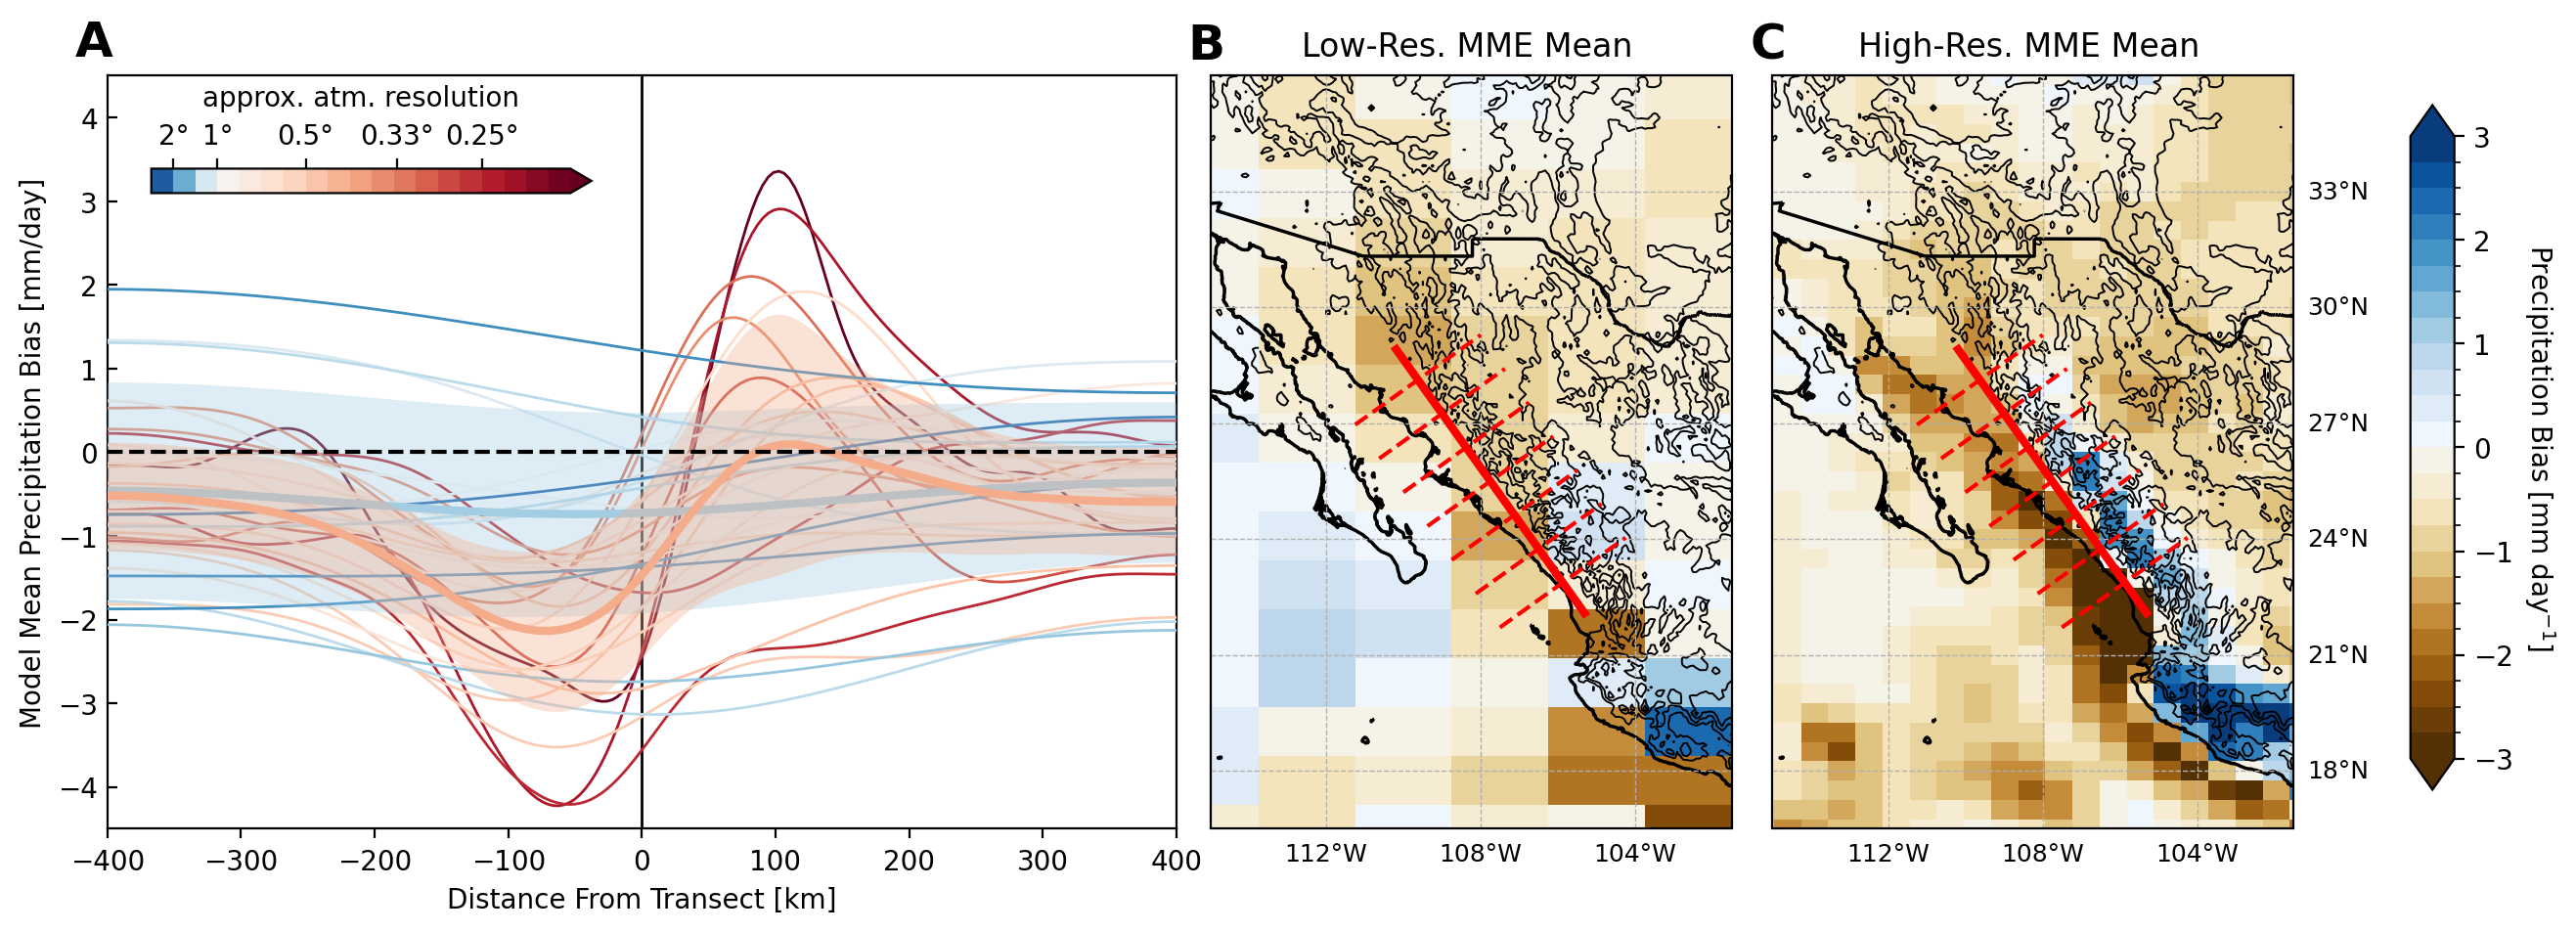

In [41]:
# settings
text_kw={'size':18, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
text_kw1={'size':12, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'center'}
tsect_text_kw={'fontsize':10, 'fontweight':'bold', 'c':'k', 'ha':'left', 'va':'bottom'}
line_kw={'ls':'-', 'lw':1, 'alpha':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':10} 
map_tkw={'color': 'black', 'weight': 'normal', 'size':9}
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20)  # discrete steps for cbar
# topography contours
zlevels=np.linspace(800,3200,5)
# transect line
npoints = 200  # resolution along the transect
lats = np.linspace(29, 22, npoints)
lons = np.linspace(-110.25, -105.25, npoints)
transect_line = LineString(zip(lons, lats))
# transect line increments
step = 500  # km
ticks = np.arange(0, distances[-1], step)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[245,258.5,16.5,36]

fig = plt.figure(figsize=(15,5), layout='constrained')
gs = gridspec.GridSpec(1, 4, width_ratios=[2,1,1,0.1], wspace=0.05)

# -------------------------
# 1) West bias / transect profile
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(-410,4.9,'A',**text_kw)
ax1.axvline(x=0, color='k', lw=1, ls='-', label='_Hidden')
ax1.axhline(y=0, color='k', lw=1.5, ls='--', label='_Hidden', zorder=100)

for key, data in reversed(transect_profiles.items()):
    nlon = len(allmodels_res[key].lon)
    color = cmap(norm(nlon))
    ax1.plot(data["bin_centers"], data["profile"], c=color, label=key, zorder=90, **line_kw)

lr_mean_nlon = 265.67
lr_med_nlon = 288
lr_color = cmap(norm(lr_mean_nlon)) #lr_med_nlon)) 
ax1.plot(bin_centers, lr_mean, color=lr_color, lw=3, ls='-', zorder=95, label='LR MME')
ax1.fill_between(bin_centers, lr_mean-lr_std, lr_mean+lr_std, color=lr_color, edgecolor=None, alpha=0.35, zorder=95)

hr_mean_nlon = 892.76
hr_med_nlon = 720
hr_color = cmap(norm(hr_mean_nlon)) #hr_med_nlon)) 
ax1.plot(bin_centers, hr_mean, color=hr_color, lw=3, ls='-', zorder=99,  label='HR MME')
ax1.fill_between(bin_centers, hr_mean-hr_std, hr_mean+hr_std, color=hr_color, edgecolor=None, alpha=0.35, zorder=99)

ax1.set_xlim([-buffer_km, buffer_km])
ax1.set_ylim([-4.5,4.5])
ax1.set_xlabel("Distance From Transect [km]")
ax1.set_ylabel("Model Mean Precipitation Bias [mm/day]")
ax1.tick_params(**tkw)

# -------------------------
# 2) LR MME mean map
# -------------------------
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.text(-115.1,36.8,'B',**text_kw)
ax2.text(-108.35,36.75,'Low-Res. MME Mean',**text_kw1)
cf_lr = ax2.pcolormesh(mme['lr'].lon, mme['lr'].lat, mme['lr'],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax2.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7,
            colors='k', transform=trans)
# Add transect line
ax2.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                   facecolor='none', edgecolor='red', lw=3, zorder=10)
# Add perpendicular cross-lines along transect
n_perp = 7
segment_len_deg = buffer_km/100  # ~1 deg/100 km approx for midlatitudes
# sample evenly along the transect
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints
for t in transect_points:
    point = transect_line.interpolate(t, normalized=True)
    lon0, lat0 = point.x, point.y
    # compute local tangent vector using finite differences
    delta = 1e-3
    p1 = transect_line.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    # perpendicular direction (−dy, dx)
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm
    # construct short line segment perpendicular to transect
    lon1 = lon0 - perp_dx * segment_len_deg / 2
    lat1 = lat0 - perp_dy * segment_len_deg / 2
    lon2 = lon0 + perp_dx * segment_len_deg / 2
    lat2 = lat0 + perp_dy * segment_len_deg / 2
    ax2.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=ccrs.PlateCarree(), zorder=9)
# add boxes around domains
#nbox = patches.Rectangle((-114.5, 28.5), 7.5, 6.5, lw=2.5, ls='--', ec='mediumorchid', fc='none', zorder=100, transform=trans); ax2.add_patch(nbox)
#fbox = patches.Rectangle((-113, 20), 9, 14, lw=2.5, ls='--', ec='darkred', fc='none', zorder=100, transform=trans); ax2.add_patch(fbox)
# map formatting
ax2.coastlines(color='k', linewidth=1.25)
ax2.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax2.set_extent(map_bnds, crs=trans)
gl=ax2.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=False
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# -------------------------
# 3) HR MME mean map
# -------------------------
ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax3.text(-115.1,36.8,'C',**text_kw)
ax3.text(-108.35,36.75,'High-Res. MME Mean',**text_kw1)
cf_hr = ax3.pcolormesh(mme['hr'].lon, mme['hr'].lat, mme['hr'],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax3.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7,
            colors='k', transform=trans)
ax3.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                   facecolor='none', edgecolor='red', lw=3, zorder=10)
# Add perpendicular cross-lines along transect
n_perp = 7
segment_len_deg = buffer_km/100  # ~1 deg/100 km approx for midlatitudes
# sample evenly along the transect
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints
for t in transect_points:
    point = transect_line.interpolate(t, normalized=True)
    lon0, lat0 = point.x, point.y
    # compute local tangent vector using finite differences
    delta = 1e-3
    p1 = transect_line.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    # perpendicular direction (−dy, dx)
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm
    # construct short line segment perpendicular to transect
    lon1 = lon0 - perp_dx * segment_len_deg / 2
    lat1 = lat0 - perp_dy * segment_len_deg / 2
    lon2 = lon0 + perp_dx * segment_len_deg / 2
    lat2 = lat0 + perp_dy * segment_len_deg / 2
    ax3.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=ccrs.PlateCarree(), zorder=9)
# add boxes around domains
#nbox = patches.Rectangle((-114.5, 28.5), 7.5, 6.5, lw=2.5, ls='--', ec='mediumorchid', fc='none', zorder=100, transform=trans); ax3.add_patch(nbox)
#fbox = patches.Rectangle((-113, 20), 9, 14, lw=2.5, ls='--', ec='darkred', fc='none', zorder=100, transform=trans); ax3.add_patch(fbox)
# map formatting
ax3.coastlines(color='k', linewidth=1.25)
ax3.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax3.set_extent(map_bnds, crs=trans)
gl=ax3.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=True
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# model resolution, convert nlons to resolution (°) for tick labels
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]

cax=fig.add_axes([0.14, .76, 0.15, 0.025])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal', cax=cax)
cbar.set_label("approx. atm. resolution", labelpad=-40, rotation=0)
cbar.ax.xaxis.set_ticks_position('top') 
cbar.set_ticklabels([f"{d:g}°" for d in dlons])

# prec bias colormap
cax=fig.add_axes([.91, 0.15, 0.015, 0.7])
cbar=fig.colorbar(cf_hr, ticks=[-3,-2,-1,0,1,2,3], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Precipitation Bias [mm day$^{-1}$]', labelpad=16, rotation=270, size=10, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

plt.savefig(f'figs/prec_bias_profile.hrmip.imerg.pdf', transparent=False, bbox_inches='tight')
plt.savefig(f'figs/prec_bias_profile.hrmip.imerg.png', transparent=False, bbox_inches='tight')

#### TRMM

In [42]:
#=== Calculate MME means ===#

# init dict
mme = { 'lr':{}, 'hr':{} }

# Define target coordinates based on lowest resolution model for LR and HR configs
# IPSL models are lowest resolution for each set
# --> 'IPSL-CM6A-LR'
# --> 'IPSL-CM6A-ATM-HR'
res_key = { 'lr':'IPSL-CM6A-LR', 'hr':'IPSL-CM6A-ATM-HR'}
prod = 'trmm'

#=== LOW RES MODELS
config='lr'
target_name = res_key[config]
target_lats = allmodels[prod][target_name].lat.values
target_lons = allmodels[prod][target_name].lon.values

# re-grid data
regridded_data=[] # Create a new xarray dataset for storing regridded data
for idx,model in enumerate(models):
    for cfg in lr_map[model]:
        ds = allmodels[prod][cfg]
        # add new coordinate to concatenate along
        ds = ds.assign_coords(source_id=cfg)
        # interp to standard grid
        ds_lr=ds.interp(lat=target_lats, lon=target_lons)
        # concatenate
        if idx==0:
            regridded_data=ds_lr
        else:
            regridded_data=xr.concat([regridded_data,ds_lr], dim='source_id', coords='minimal')
        
# calculate mme mean
mme[config] = regridded_data.mean(dim='source_id')


#=== HIGH RES MODELS
config='hr'
target_name = res_key[config]
target_lats = allmodels[prod][target_name].lat.values
target_lons = allmodels[prod][target_name].lon.values

# re-grid data
regridded_data=[] # Create a new xarray dataset for storing regridded data
for idx,model in enumerate(models):
    for cfg in hr_map[model]:
        ds = allmodels[prod][cfg]
        # add new coordinate to concatenate along
        ds = ds.assign_coords(source_id=cfg)
        # interp to standard grid
        ds_hr=ds.interp(lat=target_lats, lon=target_lons)
        # concatenate
        if idx==0:
            regridded_data=ds_hr
        else:
            regridded_data=xr.concat([regridded_data,ds_hr], dim='source_id', coords='minimal')
        
# calculate mme mean
mme[config] = regridded_data.mean(dim='source_id')


In [43]:
npoints = 200
transect_lat_max, transect_lat_min = 29, 22
transect_lon_max, transect_lon_min = 249.75, 254.75

transect_lats = np.linspace(transect_lat_max, transect_lat_min, npoints)
transect_lons = np.linspace(transect_lon_max, transect_lon_min, npoints)

# Projection centered near transect midpoint
lon0, lat0 = np.mean(transect_lons), np.mean(transect_lats)
proj = pyproj.Proj(proj="aeqd", lat_0=lat0, lon_0=lon0)

# Project transect to planar coordinates
transect_x, transect_y = proj(transect_lons, transect_lats)
transect_coords = np.column_stack((transect_x, transect_y))
transect_line = LineString(transect_coords)

buffer_km = 400
x_common = np.linspace(-buffer_km, buffer_km, 200)  # common x-axis

transect_profiles = {}

for name, da in sorted_models['trmm'].items():

    # (Optional) time average
    if 'time' in da.dims:
        da = da.mean('time')

    # Meshgrid coordinates
    lon2d, lat2d = np.meshgrid(da.lon.values, da.lat.values)
    x2d, y2d = proj(lon2d, lat2d)

    # Compute perpendicular distance (vectorized)
    # For each grid point, create a Point and compute min distance to transect
    dist_perp_2d = np.zeros_like(x2d)
    for i in range(x2d.shape[0]):
        for j in range(x2d.shape[1]):
            point = Point(x2d[i, j], y2d[i, j])
            dist_perp_2d[i, j] = point.distance(transect_line)

    # Determine sign (which side of transect)
    # East of the transect → positive
    dx = transect_x[-1] - transect_x[0]
    dy = transect_y[-1] - transect_y[0]

    # Cross-product gives direction; flip sign so east = positive
    sign = np.sign((x2d - transect_x[0]) * dy - (y2d - transect_y[0]) * dx)
    dist_perp_2d *= -sign  # flipped so east side = positive

    # Mask within ±buffer
    mask = np.abs(dist_perp_2d) <= (buffer_km * 1000)

    # Flatten valid points
    distances = dist_perp_2d[mask] / 1000  # meters → km
    precip_vals = da.values[mask]

    # Bin-average precipitation
    if len(distances) > 1:
        # Sort data for interpolation
        idx = np.argsort(distances)
        dist_sorted = distances[idx]
        prec_sorted = precip_vals[idx]

        # Interpolate onto common axis
        y_interp = np.interp(x_common, dist_sorted, prec_sorted)

        # Estimate grid spacing in km
        dlon = np.abs(np.diff(da.lon.values)).mean()
        dlat = np.abs(np.diff(da.lat.values)).mean()
        grid_km = 111 * np.sqrt(dlon**2 + dlat**2)  # rough km estimate

        dx = x_common[1] - x_common[0]
        sigma_pts = max(grid_km / dx, 1)  # sigma in points, avoid <1

        # Apply Gaussian smoothing
        profile = gaussian_filter1d(y_interp, sigma=sigma_pts)

    else:
        profile = np.full_like(x_common, np.nan)

    # Save results
    transect_profiles[name] = {
        "bin_centers": x_common,
        "profile": profile
    }


In [44]:
# stack profiles
lr_profiles = []
hr_profiles = []

for model in models:
    # low resolution
    for cfg in lr_map[model]:
        if cfg in transect_profiles:
            lr_profiles.append(transect_profiles[cfg]["profile"])

    # high resolution
    for cfg in hr_map[model]:
        if cfg in transect_profiles:
            hr_profiles.append(transect_profiles[cfg]["profile"])

lr_stack = np.array(lr_profiles)
hr_stack = np.array(hr_profiles)

hr_mean = np.nanmean(hr_stack, axis=0)
lr_mean = np.nanmean(lr_stack, axis=0)

hr_std = np.nanstd(hr_stack, axis=0)
lr_std = np.nanstd(lr_stack, axis=0)

bin_centers = transect_profiles[cfg]["bin_centers"]

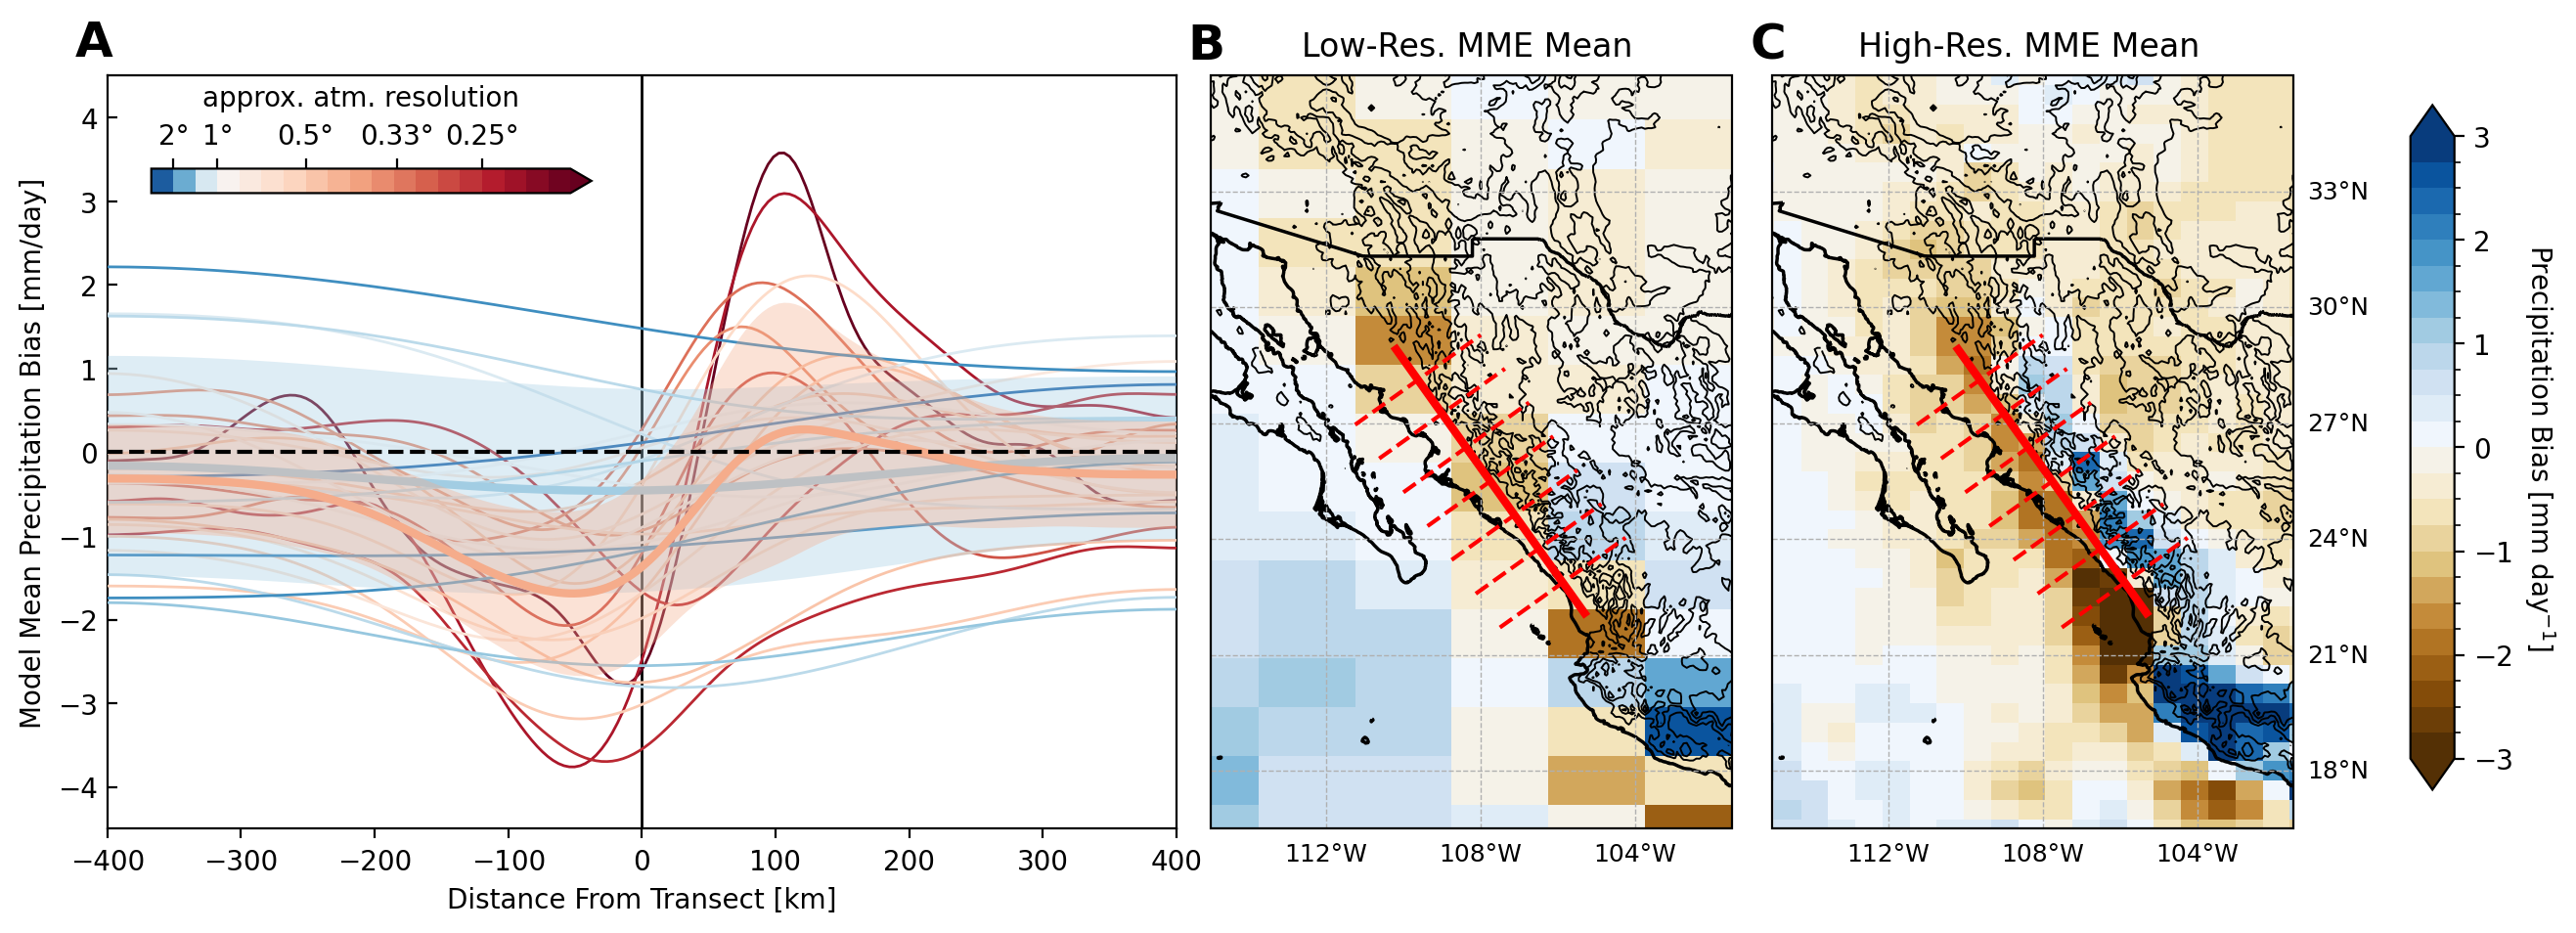

In [45]:
# settings
text_kw={'size':18, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
text_kw1={'size':12, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'center'}
tsect_text_kw={'fontsize':10, 'fontweight':'bold', 'c':'k', 'ha':'left', 'va':'bottom'}
line_kw={'ls':'-', 'lw':1, 'alpha':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':10} 
map_tkw={'color': 'black', 'weight': 'normal', 'size':9}
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20)  # discrete steps for cbar
# topography contours
zlevels=np.linspace(800,3200,5)
# transect line
npoints = 200  # resolution along the transect
lats = np.linspace(29, 22, npoints)
lons = np.linspace(-110.25, -105.25, npoints)
transect_line = LineString(zip(lons, lats))
# transect line increments
step = 500  # km
ticks = np.arange(0, distances[-1], step)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[245,258.5,16.5,36]

fig = plt.figure(figsize=(15,5), layout='constrained')
gs = gridspec.GridSpec(1, 4, width_ratios=[2,1,1,0.1], wspace=0.05)

# -------------------------
# 1) West bias / transect profile
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(-410,4.9,'A',**text_kw)
ax1.axvline(x=0, color='k', lw=1, ls='-', label='_Hidden')
ax1.axhline(y=0, color='k', lw=1.5, ls='--', label='_Hidden', zorder=100)

for key, data in reversed(transect_profiles.items()):
    nlon = len(allmodels_res[key].lon)
    color = cmap(norm(nlon))
    ax1.plot(data["bin_centers"], data["profile"], c=color, label=key, zorder=90, **line_kw)

lr_mean_nlon = 265.67
lr_med_nlon = 288
lr_color = cmap(norm(lr_mean_nlon)) #lr_med_nlon)) 
ax1.plot(bin_centers, lr_mean, color=lr_color, lw=3, ls='-', zorder=95, label='LR MME')
ax1.fill_between(bin_centers, lr_mean-lr_std, lr_mean+lr_std, color=lr_color, edgecolor=None, alpha=0.35, zorder=95)

hr_mean_nlon = 892.76
hr_med_nlon = 720
hr_color = cmap(norm(hr_mean_nlon)) #hr_med_nlon)) 
ax1.plot(bin_centers, hr_mean, color=hr_color, lw=3, ls='-', zorder=99,  label='HR MME')
ax1.fill_between(bin_centers, hr_mean-hr_std, hr_mean+hr_std, color=hr_color, edgecolor=None, alpha=0.35, zorder=99)

ax1.set_xlim([-buffer_km, buffer_km])
ax1.set_ylim([-4.5,4.5])
ax1.set_xlabel("Distance From Transect [km]")
ax1.set_ylabel("Model Mean Precipitation Bias [mm/day]")
ax1.tick_params(**tkw)

# -------------------------
# 2) LR MME mean map
# -------------------------
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.text(-115.1,36.8,'B',**text_kw)
ax2.text(-108.35,36.75,'Low-Res. MME Mean',**text_kw1)
cf_lr = ax2.pcolormesh(mme['lr'].lon, mme['lr'].lat, mme['lr'],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax2.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7,
            colors='k', transform=trans)
# Add transect line
ax2.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                   facecolor='none', edgecolor='red', lw=3, zorder=10)
# Add perpendicular cross-lines along transect
n_perp = 7
segment_len_deg = buffer_km/100  # ~1 deg/100 km approx for midlatitudes
# sample evenly along the transect
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints
for t in transect_points:
    point = transect_line.interpolate(t, normalized=True)
    lon0, lat0 = point.x, point.y
    # compute local tangent vector using finite differences
    delta = 1e-3
    p1 = transect_line.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    # perpendicular direction (−dy, dx)
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm
    # construct short line segment perpendicular to transect
    lon1 = lon0 - perp_dx * segment_len_deg / 2
    lat1 = lat0 - perp_dy * segment_len_deg / 2
    lon2 = lon0 + perp_dx * segment_len_deg / 2
    lat2 = lat0 + perp_dy * segment_len_deg / 2
    ax2.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=ccrs.PlateCarree(), zorder=9)
# add boxes around domains
#nbox = patches.Rectangle((-114.5, 28.5), 7.5, 6.5, lw=2.5, ls='--', ec='mediumorchid', fc='none', zorder=100, transform=trans); ax2.add_patch(nbox)
#fbox = patches.Rectangle((-113, 20), 9, 14, lw=2.5, ls='--', ec='darkred', fc='none', zorder=100, transform=trans); ax2.add_patch(fbox)
# map formatting
ax2.coastlines(color='k', linewidth=1.25)
ax2.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax2.set_extent(map_bnds, crs=trans)
gl=ax2.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=False
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# -------------------------
# 3) HR MME mean map
# -------------------------
ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax3.text(-115.1,36.8,'C',**text_kw)
ax3.text(-108.35,36.75,'High-Res. MME Mean',**text_kw1)
cf_hr = ax3.pcolormesh(mme['hr'].lon, mme['hr'].lat, mme['hr'],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax3.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7,
            colors='k', transform=trans)
ax3.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                   facecolor='none', edgecolor='red', lw=3, zorder=10)
# Add perpendicular cross-lines along transect
n_perp = 7
segment_len_deg = buffer_km/100  # ~1 deg/100 km approx for midlatitudes
# sample evenly along the transect
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints
for t in transect_points:
    point = transect_line.interpolate(t, normalized=True)
    lon0, lat0 = point.x, point.y
    # compute local tangent vector using finite differences
    delta = 1e-3
    p1 = transect_line.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    # perpendicular direction (−dy, dx)
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm
    # construct short line segment perpendicular to transect
    lon1 = lon0 - perp_dx * segment_len_deg / 2
    lat1 = lat0 - perp_dy * segment_len_deg / 2
    lon2 = lon0 + perp_dx * segment_len_deg / 2
    lat2 = lat0 + perp_dy * segment_len_deg / 2
    ax3.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=ccrs.PlateCarree(), zorder=9)
# add boxes around domains
#nbox = patches.Rectangle((-114.5, 28.5), 7.5, 6.5, lw=2.5, ls='--', ec='mediumorchid', fc='none', zorder=100, transform=trans); ax3.add_patch(nbox)
#fbox = patches.Rectangle((-113, 20), 9, 14, lw=2.5, ls='--', ec='darkred', fc='none', zorder=100, transform=trans); ax3.add_patch(fbox)
# map formatting
ax3.coastlines(color='k', linewidth=1.25)
ax3.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax3.set_extent(map_bnds, crs=trans)
gl=ax3.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=True
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# model resolution, convert nlons to resolution (°) for tick labels
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]

cax=fig.add_axes([0.14, .76, 0.15, 0.025])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal', cax=cax)
cbar.set_label("approx. atm. resolution", labelpad=-40, rotation=0)
cbar.ax.xaxis.set_ticks_position('top') 
cbar.set_ticklabels([f"{d:g}°" for d in dlons])

# prec bias colormap
cax=fig.add_axes([.91, 0.15, 0.015, 0.7])
cbar=fig.colorbar(cf_hr, ticks=[-3,-2,-1,0,1,2,3], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Precipitation Bias [mm day$^{-1}$]', labelpad=16, rotation=270, size=10, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

plt.savefig(f'figs/prec_bias_profile.hrmip.trmm.pdf', transparent=False, bbox_inches='tight')
plt.savefig(f'figs/prec_bias_profile.hrmip.trmm.png', transparent=False, bbox_inches='tight')

#### GPCC

In [46]:
#=== Calculate MME means ===#

# init dict
mme = { 'lr':{}, 'hr':{} }

# Define target coordinates based on lowest resolution model for LR and HR configs
# IPSL models are lowest resolution for each set
# --> 'IPSL-CM6A-LR'
# --> 'IPSL-CM6A-ATM-HR'
res_key = { 'lr':'IPSL-CM6A-LR', 'hr':'IPSL-CM6A-ATM-HR'}
prod = 'gpcc'

#=== LOW RES MODELS
config='lr'
target_name = res_key[config]
target_lats = allmodels[prod][target_name].lat.values
target_lons = allmodels[prod][target_name].lon.values

# re-grid data
regridded_data=[] # Create a new xarray dataset for storing regridded data
for idx,model in enumerate(models):
    for cfg in lr_map[model]:
        ds = allmodels[prod][cfg]
        # add new coordinate to concatenate along
        ds = ds.assign_coords(source_id=cfg)
        # interp to standard grid
        ds_lr=ds.interp(lat=target_lats, lon=target_lons)
        # concatenate
        if idx==0:
            regridded_data=ds_lr
        else:
            regridded_data=xr.concat([regridded_data,ds_lr], dim='source_id', coords='minimal')
        
# calculate mme mean
mme[config] = regridded_data.mean(dim='source_id')


#=== HIGH RES MODELS
config='hr'
target_name = res_key[config]
target_lats = allmodels[prod][target_name].lat.values
target_lons = allmodels[prod][target_name].lon.values

# re-grid data
regridded_data=[] # Create a new xarray dataset for storing regridded data
for idx,model in enumerate(models):
    for cfg in hr_map[model]:
        ds = allmodels[prod][cfg]
        # add new coordinate to concatenate along
        ds = ds.assign_coords(source_id=cfg)
        # interp to standard grid
        ds_hr=ds.interp(lat=target_lats, lon=target_lons)
        # concatenate
        if idx==0:
            regridded_data=ds_hr
        else:
            regridded_data=xr.concat([regridded_data,ds_hr], dim='source_id', coords='minimal')
        
# calculate mme mean
mme[config] = regridded_data.mean(dim='source_id')


In [47]:
npoints = 200
transect_lat_max, transect_lat_min = 29, 22
transect_lon_max, transect_lon_min = 249.75, 254.75

transect_lats = np.linspace(transect_lat_max, transect_lat_min, npoints)
transect_lons = np.linspace(transect_lon_max, transect_lon_min, npoints)

# Projection centered near transect midpoint
lon0, lat0 = np.mean(transect_lons), np.mean(transect_lats)
proj = pyproj.Proj(proj="aeqd", lat_0=lat0, lon_0=lon0)

# Project transect to planar coordinates
transect_x, transect_y = proj(transect_lons, transect_lats)
transect_coords = np.column_stack((transect_x, transect_y))
transect_line = LineString(transect_coords)

buffer_km = 400
x_common = np.linspace(-buffer_km, buffer_km, 200)  # common x-axis

transect_profiles = {}

for name, da in sorted_models['gpcc'].items():

    # (Optional) time average
    if 'time' in da.dims:
        da = da.mean('time')

    # Meshgrid coordinates
    lon2d, lat2d = np.meshgrid(da.lon.values, da.lat.values)
    x2d, y2d = proj(lon2d, lat2d)

    # Compute perpendicular distance (vectorized)
    # For each grid point, create a Point and compute min distance to transect
    dist_perp_2d = np.zeros_like(x2d)
    for i in range(x2d.shape[0]):
        for j in range(x2d.shape[1]):
            point = Point(x2d[i, j], y2d[i, j])
            dist_perp_2d[i, j] = point.distance(transect_line)

    # Determine sign (which side of transect)
    # East of the transect → positive
    dx = transect_x[-1] - transect_x[0]
    dy = transect_y[-1] - transect_y[0]

    # Cross-product gives direction; flip sign so east = positive
    sign = np.sign((x2d - transect_x[0]) * dy - (y2d - transect_y[0]) * dx)
    dist_perp_2d *= -sign  # flipped so east side = positive

    # Mask within ±buffer
    mask = np.abs(dist_perp_2d) <= (buffer_km * 1000)

    # Flatten valid points
    distances = dist_perp_2d[mask] / 1000  # meters → km
    precip_vals = da.values[mask]

    # Bin-average precipitation
    if len(distances) > 1:
        # Sort data for interpolation
        idx = np.argsort(distances)
        dist_sorted = distances[idx]
        prec_sorted = precip_vals[idx]

        # Interpolate onto common axis
        y_interp = np.interp(x_common, dist_sorted, prec_sorted)

        # Estimate grid spacing in km
        dlon = np.abs(np.diff(da.lon.values)).mean()
        dlat = np.abs(np.diff(da.lat.values)).mean()
        grid_km = 111 * np.sqrt(dlon**2 + dlat**2)  # rough km estimate

        dx = x_common[1] - x_common[0]
        sigma_pts = max(grid_km / dx, 1)  # sigma in points, avoid <1

        # Apply Gaussian smoothing
        profile = gaussian_filter1d(y_interp, sigma=sigma_pts)

    else:
        profile = np.full_like(x_common, np.nan)

    # Save results
    transect_profiles[name] = {
        "bin_centers": x_common,
        "profile": profile
    }


In [48]:
# stack profiles
lr_profiles = []
hr_profiles = []

for model in models:
    # low resolution
    for cfg in lr_map[model]:
        if cfg in transect_profiles:
            lr_profiles.append(transect_profiles[cfg]["profile"])

    # high resolution
    for cfg in hr_map[model]:
        if cfg in transect_profiles:
            hr_profiles.append(transect_profiles[cfg]["profile"])

lr_stack = np.array(lr_profiles)
hr_stack = np.array(hr_profiles)

hr_mean = np.nanmean(hr_stack, axis=0)
lr_mean = np.nanmean(lr_stack, axis=0)

hr_std = np.nanstd(hr_stack, axis=0)
lr_std = np.nanstd(lr_stack, axis=0)

bin_centers = transect_profiles[cfg]["bin_centers"]

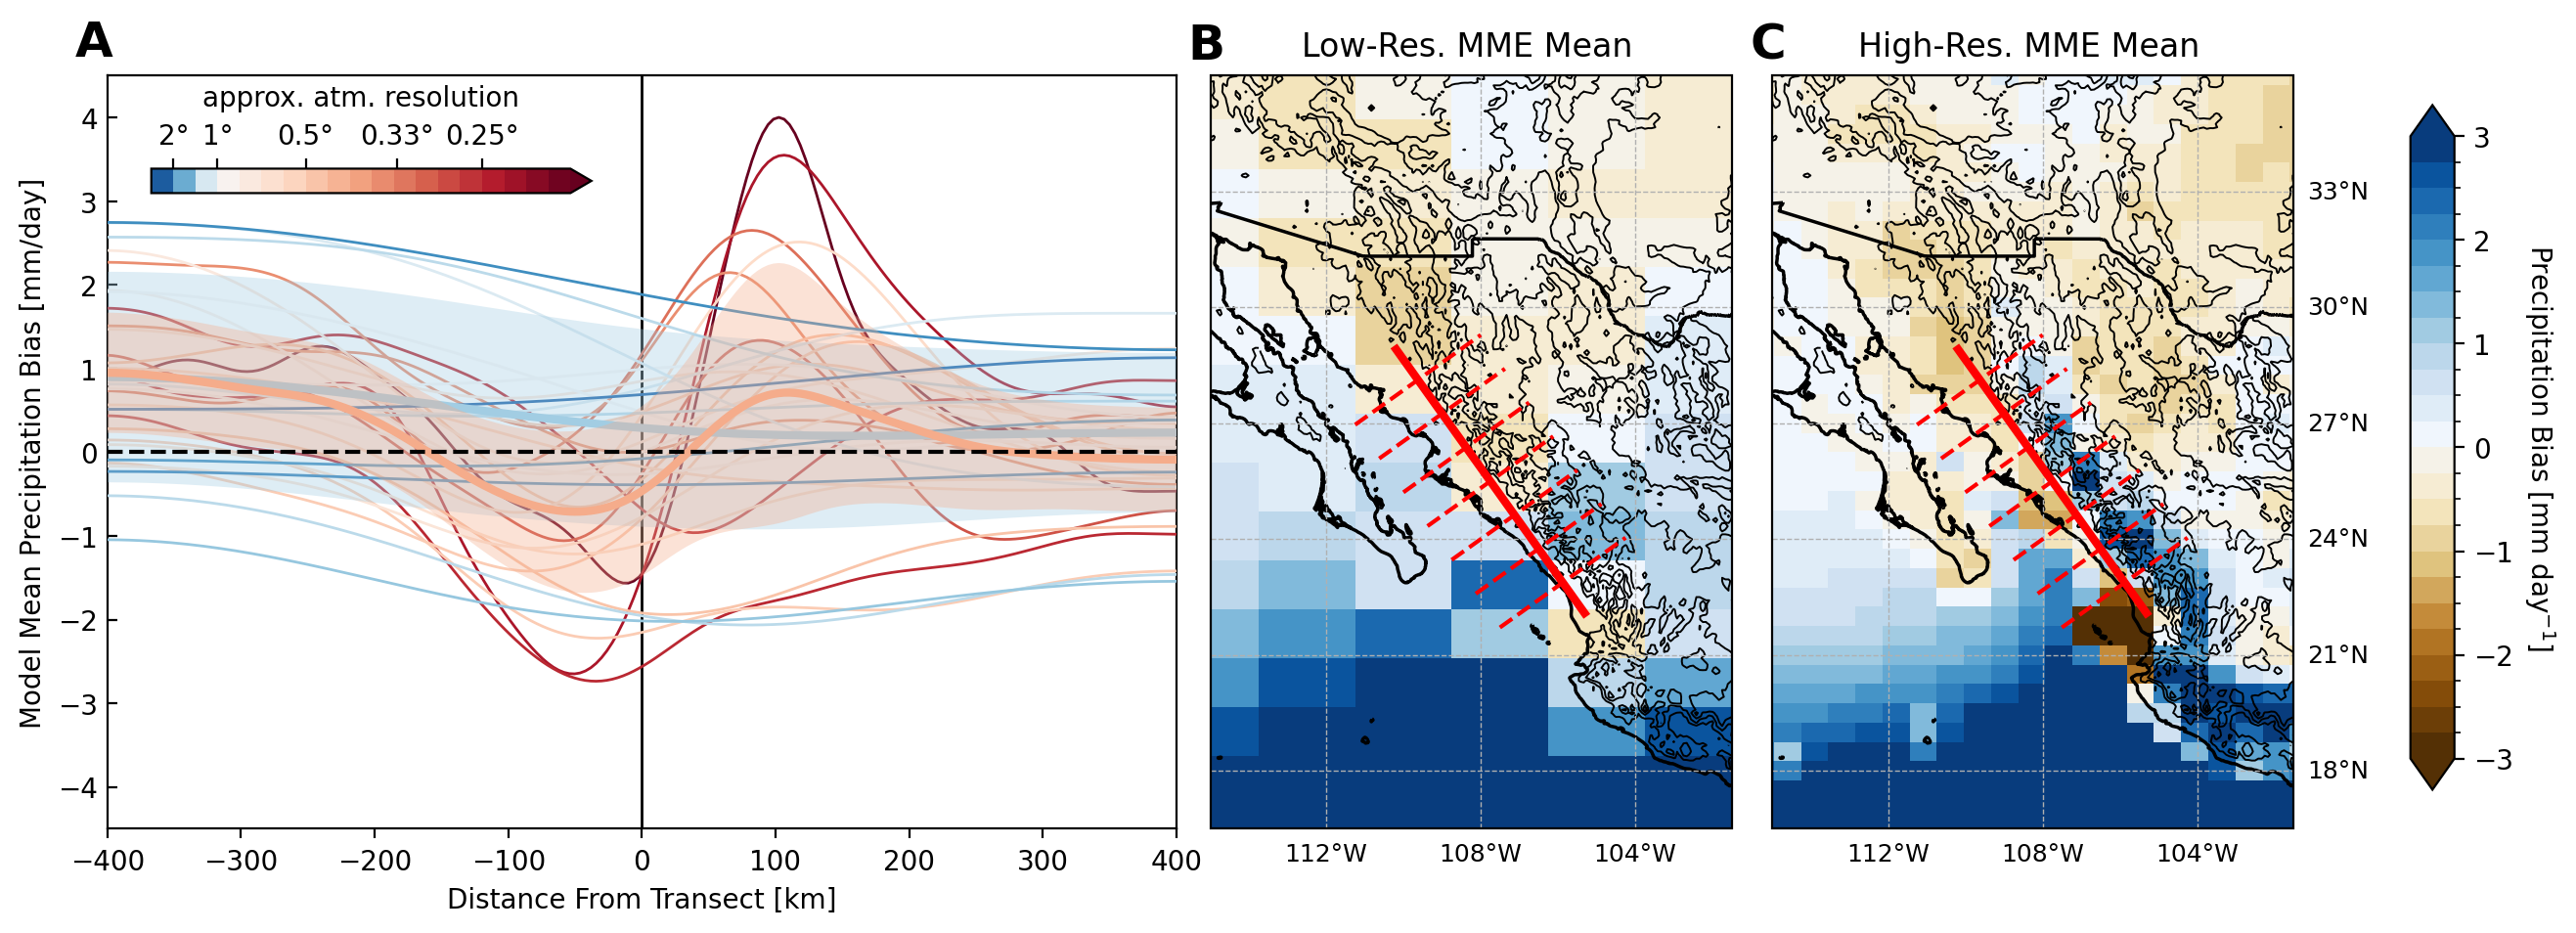

In [49]:
# settings
text_kw={'size':18, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
text_kw1={'size':12, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'center'}
tsect_text_kw={'fontsize':10, 'fontweight':'bold', 'c':'k', 'ha':'left', 'va':'bottom'}
line_kw={'ls':'-', 'lw':1, 'alpha':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':10} 
map_tkw={'color': 'black', 'weight': 'normal', 'size':9}
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20)  # discrete steps for cbar
# topography contours
zlevels=np.linspace(800,3200,5)
# transect line
npoints = 200  # resolution along the transect
lats = np.linspace(29, 22, npoints)
lons = np.linspace(-110.25, -105.25, npoints)
transect_line = LineString(zip(lons, lats))
# transect line increments
step = 500  # km
ticks = np.arange(0, distances[-1], step)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[245,258.5,16.5,36]

fig = plt.figure(figsize=(15,5), layout='constrained')
gs = gridspec.GridSpec(1, 4, width_ratios=[2,1,1,0.1], wspace=0.05)

# -------------------------
# 1) West bias / transect profile
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(-410,4.9,'A',**text_kw)
ax1.axvline(x=0, color='k', lw=1, ls='-', label='_Hidden')
ax1.axhline(y=0, color='k', lw=1.5, ls='--', label='_Hidden', zorder=100)

for key, data in reversed(transect_profiles.items()):
    nlon = len(allmodels_res[key].lon)
    color = cmap(norm(nlon))
    ax1.plot(data["bin_centers"], data["profile"], c=color, label=key, zorder=90, **line_kw)

lr_mean_nlon = 265.67
lr_med_nlon = 288
lr_color = cmap(norm(lr_mean_nlon)) #lr_med_nlon)) 
ax1.plot(bin_centers, lr_mean, color=lr_color, lw=3, ls='-', zorder=95, label='LR MME')
ax1.fill_between(bin_centers, lr_mean-lr_std, lr_mean+lr_std, color=lr_color, edgecolor=None, alpha=0.35, zorder=95)

hr_mean_nlon = 892.76
hr_med_nlon = 720
hr_color = cmap(norm(hr_mean_nlon)) #hr_med_nlon)) 
ax1.plot(bin_centers, hr_mean, color=hr_color, lw=3, ls='-', zorder=99,  label='HR MME')
ax1.fill_between(bin_centers, hr_mean-hr_std, hr_mean+hr_std, color=hr_color, edgecolor=None, alpha=0.35, zorder=99)

ax1.set_xlim([-buffer_km, buffer_km])
ax1.set_ylim([-4.5,4.5])
ax1.set_xlabel("Distance From Transect [km]")
ax1.set_ylabel("Model Mean Precipitation Bias [mm/day]")
ax1.tick_params(**tkw)

# -------------------------
# 2) LR MME mean map
# -------------------------
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.text(-115.1,36.8,'B',**text_kw)
ax2.text(-108.35,36.75,'Low-Res. MME Mean',**text_kw1)
cf_lr = ax2.pcolormesh(mme['lr'].lon, mme['lr'].lat, mme['lr'],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax2.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7,
            colors='k', transform=trans)
# Add transect line
ax2.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                   facecolor='none', edgecolor='red', lw=3, zorder=10)
# Add perpendicular cross-lines along transect
n_perp = 7
segment_len_deg = buffer_km/100  # ~1 deg/100 km approx for midlatitudes
# sample evenly along the transect
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints
for t in transect_points:
    point = transect_line.interpolate(t, normalized=True)
    lon0, lat0 = point.x, point.y
    # compute local tangent vector using finite differences
    delta = 1e-3
    p1 = transect_line.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    # perpendicular direction (−dy, dx)
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm
    # construct short line segment perpendicular to transect
    lon1 = lon0 - perp_dx * segment_len_deg / 2
    lat1 = lat0 - perp_dy * segment_len_deg / 2
    lon2 = lon0 + perp_dx * segment_len_deg / 2
    lat2 = lat0 + perp_dy * segment_len_deg / 2
    ax2.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=ccrs.PlateCarree(), zorder=9)
# add boxes around domains
#nbox = patches.Rectangle((-114.5, 28.5), 7.5, 6.5, lw=2.5, ls='--', ec='mediumorchid', fc='none', zorder=100, transform=trans); ax2.add_patch(nbox)
#fbox = patches.Rectangle((-113, 20), 9, 14, lw=2.5, ls='--', ec='darkred', fc='none', zorder=100, transform=trans); ax2.add_patch(fbox)
# map formatting
ax2.coastlines(color='k', linewidth=1.25)
ax2.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax2.set_extent(map_bnds, crs=trans)
gl=ax2.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=False
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# -------------------------
# 3) HR MME mean map
# -------------------------
ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax3.text(-115.1,36.8,'C',**text_kw)
ax3.text(-108.35,36.75,'High-Res. MME Mean',**text_kw1)
cf_hr = ax3.pcolormesh(mme['hr'].lon, mme['hr'].lat, mme['hr'],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax3.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7,
            colors='k', transform=trans)
ax3.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                   facecolor='none', edgecolor='red', lw=3, zorder=10)
# Add perpendicular cross-lines along transect
n_perp = 7
segment_len_deg = buffer_km/100  # ~1 deg/100 km approx for midlatitudes
# sample evenly along the transect
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints
for t in transect_points:
    point = transect_line.interpolate(t, normalized=True)
    lon0, lat0 = point.x, point.y
    # compute local tangent vector using finite differences
    delta = 1e-3
    p1 = transect_line.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    # perpendicular direction (−dy, dx)
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm
    # construct short line segment perpendicular to transect
    lon1 = lon0 - perp_dx * segment_len_deg / 2
    lat1 = lat0 - perp_dy * segment_len_deg / 2
    lon2 = lon0 + perp_dx * segment_len_deg / 2
    lat2 = lat0 + perp_dy * segment_len_deg / 2
    ax3.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=ccrs.PlateCarree(), zorder=9)
# add boxes around domains
#nbox = patches.Rectangle((-114.5, 28.5), 7.5, 6.5, lw=2.5, ls='--', ec='mediumorchid', fc='none', zorder=100, transform=trans); ax3.add_patch(nbox)
#fbox = patches.Rectangle((-113, 20), 9, 14, lw=2.5, ls='--', ec='darkred', fc='none', zorder=100, transform=trans); ax3.add_patch(fbox)
# map formatting
ax3.coastlines(color='k', linewidth=1.25)
ax3.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax3.set_extent(map_bnds, crs=trans)
gl=ax3.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=True
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# model resolution, convert nlons to resolution (°) for tick labels
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]

cax=fig.add_axes([0.14, .76, 0.15, 0.025])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal', cax=cax)
cbar.set_label("approx. atm. resolution", labelpad=-40, rotation=0)
cbar.ax.xaxis.set_ticks_position('top') 
cbar.set_ticklabels([f"{d:g}°" for d in dlons])

# prec bias colormap
cax=fig.add_axes([.91, 0.15, 0.015, 0.7])
cbar=fig.colorbar(cf_hr, ticks=[-3,-2,-1,0,1,2,3], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Precipitation Bias [mm day$^{-1}$]', labelpad=16, rotation=270, size=10, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

plt.savefig(f'figs/prec_bias_profile.hrmip.gpcc.pdf', transparent=False, bbox_inches='tight')
plt.savefig(f'figs/prec_bias_profile.hrmip.gpcc.png', transparent=False, bbox_inches='tight')

### FIG WITH BOX PLOTS

In [ ]:
# ---- define transect (lon/lat) ----
transect_lats = np.linspace(transect_lat_max, transect_lat_min, npoints)
transect_lons = np.linspace(transect_lon_max, transect_lon_min, npoints)

# ---- projection centered on transect ----
lon0, lat0 = np.mean(transect_lons), np.mean(transect_lats)
aeqd_proj = pyproj.Proj(proj="aeqd", lat_0=lat0, lon_0=lon0)

# ---- projected geometry (meters) ----
transect_x, transect_y = aeqd_proj(transect_lons, transect_lats)
transect_coords = np.column_stack((transect_x, transect_y))
transect_line_xy = LineString(transect_coords)   # meters

# ---- map geometry (degrees) ----
map_proj = ccrs.PlateCarree()
transect_line_ll = LineString(zip(transect_lons, transect_lats))  # degrees
xs, ys = transect_line_ll.xy

buffer_km = 400
bin_width = 50  # km
bins = np.arange(-buffer_km, buffer_km + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])


transect_profiles = {}

for name, da in sorted_models['imerg'].items():

    # (Optional) time average
    if 'time' in da.dims:
        da = da.mean('time')

    # crude grid spacing estimate (km)
    dlon = np.abs(np.diff(da.lon.values)).mean()
    dlat = np.abs(np.diff(da.lat.values)).mean()

    # Meshgrid coordinates
    lon2d, lat2d = np.meshgrid(da.lon.values, da.lat.values)
    x2d, y2d = aeqd_proj(lon2d, lat2d)

    # Compute perpendicular distance to transect
    # For each grid point, create a Point and compute min distance to transect
    dist_perp_2d = np.zeros_like(x2d)
    for i in range(x2d.shape[0]):
        for j in range(x2d.shape[1]):
            point = Point(x2d[i, j], y2d[i, j])
            dist_perp_2d[i, j] = point.distance(transect_line_xy)

    # Determine sign (which side of transect)
    # East of the transect → positive
    dx = transect_x[-1] - transect_x[0]
    dy = transect_y[-1] - transect_y[0]

    # Cross-product gives direction; flip sign so east = positive
    sign = np.sign((x2d - transect_x[0]) * dy - (y2d - transect_y[0]) * dx)
    dist_perp_2d *= -sign  # flipped so east side = positive


    # Mask within ±buffer
    mask = np.abs(dist_perp_2d) <= (buffer_km * 1000)

    # Flatten valid points
    distances = dist_perp_2d[mask] / 1000  # meters → km
    precip_vals = da.values[mask]

    # Bin-average precipitation
    if len(distances) > 1:
        profile = np.full(len(bin_centers), np.nan)
    
        # assign each grid point to a distance bin
        inds = np.digitize(distances, bins) - 1
    
        for i in range(len(bin_centers)):
            mask_i = inds == i
            if np.any(mask_i):
                profile[i] = np.nanmean(precip_vals[mask_i])
    
    else:
        profile = np.full(len(bin_centers), np.nan)
    
    # Save results
    transect_profiles[name] = {
        "bin_centers": bin_centers,
        "profile": profile
    }

# Only keep bins with at least one model contributing
valid_bins = ~np.all(
    np.vstack([p["profile"] for p in transect_profiles.values()]),
    axis=0
)

bin_centers = bin_centers[valid_bins]

for k in transect_profiles:
    transect_profiles[k]["profile"] = transect_profiles[k]["profile"][valid_bins]


In [ ]:
# --- collect LR / HR samples per distance bin ---
lr_samples = [[] for _ in bin_centers]
hr_samples = [[] for _ in bin_centers]

for model in models:

    # low-resolution members
    for cfg in lr_map[model]:
        if cfg in transect_profiles:
            prof = transect_profiles[cfg]["profile"]
            for i, val in enumerate(prof):
                if np.isfinite(val):
                    lr_samples[i].append(val)

    # high-resolution members
    for cfg in hr_map[model]:
        if cfg in transect_profiles:
            prof = transect_profiles[cfg]["profile"]
            for i, val in enumerate(prof):
                if np.isfinite(val):
                    hr_samples[i].append(val)

lr_median = np.array([np.nanmedian(v) if len(v) else np.nan for v in lr_samples])
hr_median = np.array([np.nanmedian(v) if len(v) else np.nan for v in hr_samples])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example: lr_samples, hr_samples, bin_centers
# Make sure they are lists of lists of numbers
# For demonstration, generate fake data if not available
if 'lr_samples' not in globals():
    np.random.seed(0)
    n_bins = 10
    bin_centers = np.linspace(-400, 400, n_bins)
    lr_samples = [np.random.normal(loc=0, scale=1, size=5).tolist() for _ in bin_centers]
    hr_samples = [np.random.normal(loc=0.5, scale=1, size=5).tolist() for _ in bin_centers]

# Calculate medians
lr_median = np.array([np.nanmedian(v) if len(v) else np.nan for v in lr_samples])
hr_median = np.array([np.nanmedian(v) if len(v) else np.nan for v in hr_samples])

# Plot
fig, ax = plt.subplots(figsize=(8,5))

# Box widths and offsets
bin_width = bin_centers[1] - bin_centers[0]
offset = bin_width * 0.18
pos_lr = bin_centers - offset
pos_hr = bin_centers + offset

# LR boxplots
ax.boxplot(
    lr_samples,
    positions=pos_lr,
    widths=bin_width * 0.3,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='none', edgecolor='k', lw=1.5),
    medianprops=dict(color='k', lw=2),
    whiskerprops=dict(color='k'),
    capprops=dict(color='k')
)

# HR boxplots
ax.boxplot(
    hr_samples,
    positions=pos_hr,
    widths=bin_width * 0.3,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='k', alpha=0.25, edgecolor='k', lw=1.5),
    medianprops=dict(color='k', lw=2),
    whiskerprops=dict(color='k'),
    capprops=dict(color='k')
)

# Medians as lines
ax.plot(bin_centers, lr_median, 'k--', lw=2, label='LR median')
ax.plot(bin_centers, hr_median, 'k-', lw=2, label='HR median')

# Labels and limits
ax.set_xlabel("Distance From Transect [km]")
ax.set_ylabel("Model Mean Precipitation Bias [mm/day]")
ax.set_xlim([-400, 400])
ax.set_ylim([-4.5, 4.5])
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [ ]:
# settings
text_kw={'size':18, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
text_kw1={'size':12, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'center'}
tsect_text_kw={'fontsize':10, 'fontweight':'bold', 'c':'k', 'ha':'left', 'va':'bottom'}
line_kw={'ls':'-', 'lw':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':10} 
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20)  # discrete steps for cbar
# topography contours
zlevels=np.linspace(800,3200,5)
# transect line
npoints = 200  # resolution along the transect
lats = np.linspace(29, 22, npoints)
lons = np.linspace(-110.25, -105.25, npoints)
transect_line = LineString(zip(lons, lats))
# transect line increments
step = 500  # km
ticks = np.arange(0, distances[-1], step)
# map specs
trans=ccrs.PlateCarree()
map_proj=ccrs.PlateCarree()

map_bnds=[246,258.5,17,35]

fig = plt.figure(figsize=(15,5), layout='constrained')
gs = gridspec.GridSpec(1, 4, width_ratios=[2,1,1,0.1], wspace=0.05)

# -------------------------
# 1) West bias / transect profile
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(-410,4.9,'A',**text_kw)
ax1.axvline(x=0, color='k', lw=1, ls='-', label='_Hidden')
ax1.axhline(y=0, color='k', lw=2, ls='--', label='_Hidden', zorder=100)

# horizontal offsets for side-by-side boxplots
offset = bin_width * 0.18
pos_lr = bin_centers - offset
pos_hr = bin_centers + offset

# LR boxplots
ax1.boxplot(
    lr_samples,
    positions=pos_lr,
    widths=bin_width * 0.3,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='none', edgecolor='k', lw=1.5),
    medianprops=dict(color='k', lw=2),
    whiskerprops=dict(color='k'),
    capprops=dict(color='k')
)

# HR boxplots
ax1.boxplot(
    hr_samples,
    positions=pos_hr,
    widths=bin_width * 0.3,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='k', alpha=0.25, edgecolor='k', lw=1.5),
    medianprops=dict(color='k', lw=2),
    whiskerprops=dict(color='k'),
    capprops=dict(color='k')
)

ax1.plot(bin_centers, lr_median, 'k--', lw=2, label='LR median')
ax1.plot(bin_centers, hr_median, 'k-',  lw=2, label='HR median')

ax1.set_xlim([-buffer_km, buffer_km])
ax1.set_xbound(-buffer_km, buffer_km)
ax1.set_ylim([-4.5,4.5])
ax1.set_xlabel("Distance From Transect [km]")
ax1.set_ylabel("Model Mean Precipitation Bias [mm/day]")
ax1.tick_params(**tkw)

# -------------------------
# 2) LR MME mean map
# -------------------------
ax2 = fig.add_subplot(gs[0, 1], projection=map_proj)
ax2.text(-114.1, 35.5, 'B', **text_kw)
ax2.text(-107.85, 35.75, 'Low Res. MME Mean', **text_kw1)

# main field
cf_lr = ax2.pcolormesh(mme['lr'].lon, mme['lr'].lat, mme['lr'],
                       cmap=dcmap, norm=dnorm, transform=map_proj)

# topography contours
ax2.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=0.5,
            colors='k', transform=map_proj)

# transect line
ax2.add_geometries([transect_line_ll], crs=map_proj,
                   facecolor='none', edgecolor='red', lw=3, zorder=10)

# perpendicular cross-lines
n_perp = 7
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints

for t in transect_points:
    # interpolate along transect (projected meters)
    point = transect_line_xy.interpolate(t, normalized=True)
    x0, y0 = point.x, point.y

    # finite-difference tangent
    delta = 1e-3
    p1 = transect_line_xy.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line_xy.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y

    # perpendicular vector
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm

    # endpoints of perpendicular segment
    x1 = x0 - perp_dx * segment_len_m / 2
    y1 = y0 - perp_dy * segment_len_m / 2
    x2 = x0 + perp_dx * segment_len_m / 2
    y2 = y0 + perp_dy * segment_len_m / 2

    # convert back to lat/lon for plotting
    lon1, lat1 = aeqd_proj(x1, y1, inverse=True)
    lon2, lat2 = aeqd_proj(x2, y2, inverse=True)

    ax2.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=map_proj, zorder=9)

# coastlines, borders, extent
ax2.coastlines(color='k', linewidth=1.25)
ax2.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax2.set_extent(map_bnds, crs=map_proj)


# -------------------------
# 3) HR MME mean map
# -------------------------
ax3 = fig.add_subplot(gs[0, 2], projection=map_proj)
ax3.text(-114.1, 35.5, 'C', **text_kw)
ax3.text(-107.85, 35.75, 'High Res. MME Mean', **text_kw1)

cf_hr = ax3.pcolormesh(mme['hr'].lon, mme['hr'].lat, mme['hr'],
                       cmap=dcmap, norm=dnorm, transform=map_proj)
ax3.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=0.5,
            colors='k', transform=map_proj)

ax3.add_geometries([transect_line_ll], crs=map_proj,
                   facecolor='none', edgecolor='red', lw=3, zorder=10)

# perpendicular cross-lines
for t in transect_points:
    point = transect_line_xy.interpolate(t, normalized=True)
    x0, y0 = point.x, point.y

    delta = 1e-3
    p1 = transect_line_xy.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line_xy.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y

    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm

    x1 = x0 - perp_dx * segment_len_m / 2
    y1 = y0 - perp_dy * segment_len_m / 2
    x2 = x0 + perp_dx * segment_len_m / 2
    y2 = y0 + perp_dy * segment_len_m / 2

    lon1, lat1 = aeqd_proj(x1, y1, inverse=True)
    lon2, lat2 = aeqd_proj(x2, y2, inverse=True)

    ax3.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=map_proj, zorder=9)

ax3.coastlines(color='k', linewidth=1.25)
ax3.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax3.set_extent(map_bnds, crs=map_proj)



# model resolution, convert nlons to resolution (°) for tick labels
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]

cax=fig.add_axes([0.14, .76, 0.15, 0.025])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal', cax=cax)
cbar.set_label("approx. atm. resolution", labelpad=-40, rotation=0)
cbar.ax.xaxis.set_ticks_position('top') 
cbar.set_ticklabels([f"{d:g}°" for d in dlons])

# prec bias colormap
cax=fig.add_axes([.88, 0.15, 0.015, 0.7])
cbar=fig.colorbar(cf_hr, ticks=[-3,-2,-1,0,1,2,3], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Precipitation Bias [mm day$^{-1}$]', labelpad=16, rotation=270, size=10, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')


### FIG NO MEAN LINES

In [ ]:
# settings
text_kw={'size':18, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
text_kw1={'size':12, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'center'}
tsect_text_kw={'fontsize':10, 'fontweight':'bold', 'c':'k', 'ha':'left', 'va':'bottom'}
line_kw={'ls':'-', 'lw':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':10} 
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20)  # discrete steps for cbar
# topography contours
zlevels=np.linspace(800,3200,5)
# transect line
npoints = 200  # resolution along the transect
lats = np.linspace(29, 22, npoints)
lons = np.linspace(-110.25, -105.25, npoints)
transect_line = LineString(zip(lons, lats))
# transect line increments
step = 500  # km
ticks = np.arange(0, distances[-1], step)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[246,258.5,17,35]

fig = plt.figure(figsize=(15,5), layout='constrained')
gs = gridspec.GridSpec(1, 4, width_ratios=[2,1,1,0.1], wspace=0.05)

# -------------------------
# 1) West bias / transect profile
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(-410,4.9,'A',**text_kw)
ax1.axvline(x=0, color='k', lw=1, ls='-', label='_Hidden')
ax1.axhline(y=0, color='k', lw=2, ls='--', label='_Hidden', zorder=100)

for key, data in reversed(transect_profiles.items()):
    nlon = len(allmodels_res[key].lon)
    color = cmap(norm(nlon))
    ax1.plot(data["bin_centers"], data["profile"], c=color, label=key, **line_kw)

ax1.set_xlim([-buffer_km, buffer_km])
ax1.set_ylim([-4.5,4.5])
ax1.set_xlabel("Distance From Transect [km]")
ax1.set_ylabel("Model Mean Precipitation Bias [mm/day]")
ax1.tick_params(**tkw)

# -------------------------
# 2) LR MME mean map
# -------------------------
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.text(-114.1,35.5,'B',**text_kw)
ax2.text(-107.85,35.75,'Low Res. MME Mean',**text_kw1)
cf_lr = ax2.pcolormesh(mme['lr'].lon, mme['lr'].lat, mme['lr'],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax2.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=0.5,
            colors='k', transform=trans)
# Add transect line
ax2.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                   facecolor='none', edgecolor='red', lw=3, zorder=10)
# Add perpendicular cross-lines along transect
n_perp = 7
segment_len_deg = buffer_km/100  # ~1 deg/100 km approx for midlatitudes
# sample evenly along the transect
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints
for t in transect_points:
    point = transect_line.interpolate(t, normalized=True)
    lon0, lat0 = point.x, point.y
    # compute local tangent vector using finite differences
    delta = 1e-3
    p1 = transect_line.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    # perpendicular direction (−dy, dx)
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm
    # construct short line segment perpendicular to transect
    lon1 = lon0 - perp_dx * segment_len_deg / 2
    lat1 = lat0 - perp_dy * segment_len_deg / 2
    lon2 = lon0 + perp_dx * segment_len_deg / 2
    lat2 = lat0 + perp_dy * segment_len_deg / 2
    ax2.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=ccrs.PlateCarree(), zorder=9)
ax2.coastlines(color='k', linewidth=1.25)
ax2.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax2.set_extent(map_bnds, crs=trans)

# -------------------------
# 3) HR MME mean map
# -------------------------
ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax3.text(-114.1,35.5,'C',**text_kw)
ax3.text(-107.85,35.75,'High Res. MME Mean',**text_kw1)
cf_hr = ax3.pcolormesh(mme['hr'].lon, mme['hr'].lat, mme['hr'],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax3.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=0.5,
            colors='k', transform=trans)
ax3.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                   facecolor='none', edgecolor='red', lw=3, zorder=10)
# Add perpendicular cross-lines along transect
n_perp = 7
segment_len_deg = buffer_km/100  # ~1 deg/100 km approx for midlatitudes
# sample evenly along the transect
transect_points = np.linspace(0, 1, n_perp + 2)[1:-1]  # skip endpoints
for t in transect_points:
    point = transect_line.interpolate(t, normalized=True)
    lon0, lat0 = point.x, point.y
    # compute local tangent vector using finite differences
    delta = 1e-3
    p1 = transect_line.interpolate(max(0, t - delta), normalized=True)
    p2 = transect_line.interpolate(min(1, t + delta), normalized=True)
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    # perpendicular direction (−dy, dx)
    perp_dx, perp_dy = -dy, dx
    tnorm = np.sqrt(perp_dx**2 + perp_dy**2)
    perp_dx /= tnorm
    perp_dy /= tnorm
    # construct short line segment perpendicular to transect
    lon1 = lon0 - perp_dx * segment_len_deg / 2
    lat1 = lat0 - perp_dy * segment_len_deg / 2
    lon2 = lon0 + perp_dx * segment_len_deg / 2
    lat2 = lat0 + perp_dy * segment_len_deg / 2
    ax3.plot([lon1, lon2], [lat1, lat2],
             color='red', lw=1.5, ls='--',
             transform=ccrs.PlateCarree(), zorder=9)
ax3.coastlines(color='k', linewidth=1.25)
ax3.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax3.set_extent(map_bnds, crs=trans)


# model resolution, convert nlons to resolution (°) for tick labels
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]

cax=fig.add_axes([0.14, .76, 0.15, 0.025])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal', cax=cax)
cbar.set_label("approx. atm. resolution", labelpad=-40, rotation=0)
cbar.ax.xaxis.set_ticks_position('top') 
cbar.set_ticklabels([f"{d:g}°" for d in dlons])

# prec bias colormap
cax=fig.add_axes([.88, 0.15, 0.015, 0.7])
cbar=fig.colorbar(cf_hr, ticks=[-3,-2,-1,0,1,2,3], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Precipitation Bias [mm day$^{-1}$]', labelpad=16, rotation=270, size=10, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')
